In [1]:
import sys
sys.path.append('/home/aribra/jnps/thesis/public_repo/lattice_correction_net')
import numpy as np
from pylab import *

from synchrotron_simulator_gpu_Dataset_4D import SimulationRunner, SynchrotronSimulator
from automate_dataset_collection import SimulationDataset
import time

In [2]:
! pwd


/home/aribra/jnps/thesis/public_repo/lattice_correction_net/notebooks


In [3]:
# theta_kick = (k_nominal * delta * L_quad)  # Small angular kick

### Configurations

In [4]:
np.rad2deg(1.8)

103.13240312354819

In [5]:
np.deg2rad(30)

0.5235987755982988

In [365]:
# Define base simulation configurations with embedded quadrupole errors


base_configurations = [
    {
        'config_name': 'Configuration 1',
        'design_radius': 200,    # meters
        'n_FODO': 100,
        'f': 15,                 # meters
        'L_quad': 1,             # meters
        'n_Dipoles': 200,
        'L_straight': 0.1,         # meters
        # 'L_straight': 1,         # meters
        # 'total_dipole_bending_angle': (2 * np.pi),#(3 / 3) * np.pi,

        'quad_errors': [
            # {
            #     'FODO_index': 0,
            #     'quad_type': 'defocusing',
            #     'delta': 2,
            #     'plane': 'vertical'  # 'horizontal' or 'vertical'
            # },
            # {
            #     'FODO_index': 1,
            #     'quad_type': 'defocusing',
            #     'delta': 1e-6,
            #     'plane': 'vertical'  # 'horizontal' or 'vertical'
            # },
            {
                'FODO_index': 10,
                'quad_type': 'defocusing',
                'delta': 1e-4,
                'plane': 'vertical'  # 'horizontal' or 'vertical'
            },
            # {
            #     'FODO_index': 3,
            #     'quad_type': 'defocusing',
            #     'delta': 1e-7,
            #     'plane': 'vertical'  # 'horizontal' or 'vertical'
            # },
            # {
            #     'FODO_index': 4,
            #     'quad_type': 'defocusing',
            #     'delta': 1e-7,
            #     'plane': 'vertical'  # 'horizontal' or 'vertical'
            # },
            # {
            #     'FODO_index': 5,
            #     'quad_type': 'defocusing',
            #     'delta': 1e-7,
            #     'plane': 'vertical'  # 'horizontal' or 'vertical'
            # },
            # # {
            # #     'FODO_index': 6,
            # #     'quad_type': 'defocusing',
            # #     'delta': 1e-7,
            # #     'plane': 'vertical'  # 'horizontal' or 'vertical'
            # # },
            # {
            #     'FODO_index': 7,
            #     'quad_type': 'defocusing',
            #     'delta': 1e-7,
            #     'plane': 'vertical'  # 'horizontal' or 'vertical'
            # },
        ],
        
        "dipole_tilt_errors": None,
        
        'quad_tilt_errors': [
            # {
            #     'FODO_index': 1,
            #     'quad_type': 'defocusing',
            #     'tilt_angle': -0.349066
            # },
            # {
            #     'FODO_index': 3,
            #     'quad_type': 'defocusing',
            #     'tilt_angle': 0.349066
            # },
            # {
            #     'FODO_index': 6,
            #     'quad_type': 'defocusing',
            #     'tilt_angle': 0.5
            # },   
        ],
        
        # "quad_tilt_errors": None,
        
    },
]

common_parameters = {
    'p': 5.344286e-19,                # Momentum in kg m/s (p_GeV_c=0.7)
    'G': 0.5,                         # Tesla/meter
    'q': 1.602e-19,                   # Proton charge in Coulombs
    'n_turns': 1,                   # Number of revolutions to simulate
    'num_particles': 1,             # Number of particles to simulate
    'window_size': 10,                # Average window size for moving averages
    'use_thin_lens': True,
    # Uniform - Initial conditions ranges as tuples
    'x0_mean_std': (0.0, 0.05),      # meters
    'xp0_mean_std': (0.0, 0.00),  # radians
    'y0_mean_std': (0.0, 0.05),      # meters
    'yp0_mean_std': (0.0, 0.00),  # radians
    'particles_sampling_method': 'from_twiss_params', # from_twiss_params | circle_with_radius | normal
    'correct_injection_offset': False,
    'sampling_circle_radius': 0.01, #meters,
    # Acceptable ranges config params
    'mag_field_range': [0.015, 20.0],           # Tesla
    'dipole_length_range': [0.1, 14.0],       # meters
    'horizontal_tune_range': [0.01, 0.8],     # Tune
    'vertical_tune_range': [0.01, 0.8],        # Tune
    'total_dipole_bending_angle_range': (1.5 * np.pi, 2 * np.pi),
    # Use cuda GPU kernels to accelerate simulation
    'use_gpu': True,
    # Log
    'verbose': True,
    # BPM readings log criterion
    # record_full_revolution. By default records for cell_idx=0
    # 'record_full_revolution': False,
    # enable storing BPM readings for all BPMs after each full revolution relative to each BPM
    # requires to set record_full_revolution to `True`
    # 'record_full_revolution_per_bpm': False,

    # Parameters for generate_data
    'target_data': 'quad_misalign_deltas',  # ['quad_misalign_deltas', 'quad_tilt_angles', 'dipole_tilt_angles']
    'reject_multiple_error_types': False,
    'start_rev': 1500,
    'end_rev': 2000, # should be same as <= n_turns
    'apply_avg': True,
    'fodo_cell_indices': [0, 1, 2, 3, 4, 5, 6, 7],  # Indices of BPMs to consider
    'planes': ['x', 'y'],
    'random_criterion': 'normal', # uniform | normal
    # if 'random_criterion' is 'uniform'
        # then >> _range is (low, high)
    # if 'random_criterion' is 'normal'
        # then >> _range is (mean, std)
    'delta_range': (0, 5e-5),
    'quad_tilt_angle_range': (-0.10, 0.10), # 100 mrad (1e-3 = 1 mrad)
    'dipole_tilt_angle_range': (0, 0.05), # 50 mrad
    'com_delta_range': (-50e-6, 50e-6),
}


In [366]:
base_configurations

[{'config_name': 'Configuration 1',
  'design_radius': 200,
  'n_FODO': 100,
  'f': 15,
  'L_quad': 1,
  'n_Dipoles': 200,
  'L_straight': 0.1,
  'quad_errors': [{'FODO_index': 10,
    'quad_type': 'defocusing',
    'delta': 0.0001,
    'plane': 'vertical'}],
  'dipole_tilt_errors': None,
  'quad_tilt_errors': []}]

In [367]:
sampling_func = None
if common_parameters['random_criterion'] == 'uniform':
    sampling_func = np.random.uniform
elif common_parameters['random_criterion'] == 'normal':
    sampling_func = np.random.normal


# Target prediction (Misalignment)
quadrupole_errors_target_values = {}

base_config = base_configurations[0]

if base_config['quad_errors']:
    fodo_indices_with_error = [err['FODO_index'] for err in base_config['quad_errors']]
else:
    fodo_indices_with_error = []

if base_config['quad_tilt_errors']:
    fodo_indices_with_quad_tilt_error = [err['FODO_index'] for err in base_config['quad_tilt_errors']]
else:
    fodo_indices_with_quad_tilt_error = []

mean_or_min_delta, std_or_max_delta = common_parameters['delta_range']
mean_or_min_quad_tilt_error, std_or_max_quad_tilt_error = common_parameters['quad_tilt_angle_range']

# # Apply quad misalignment errors
# if base_config['quad_errors']:
#     for qe_ix, qe in enumerate(base_config['quad_errors']):
#         if base_config['quad_errors'][qe_ix]['FODO_index'] in fodo_indices_with_error:
#             quadrupole_error_delta = sampling_func(mean_or_min_delta, std_or_max_delta)
#             quadrupole_errors_target_values[qe_ix] = quadrupole_error_delta
#             base_config['quad_errors'][qe_ix]['delta'] = quadrupole_error_delta
#             print("_run_evaluation()/ ", qe_ix, qe)
#         else:
#             base_config['quad_errors'][qe_ix]['delta'] = 0.0

# Apply quad_tilt_errors
if base_config['quad_tilt_errors']:
    for qe_ix, qe in enumerate(base_config['quad_tilt_errors']):
        if base_config['quad_tilt_errors'][qe_ix]['FODO_index'] in fodo_indices_with_quad_tilt_error:
            quadrupole_tilt_error_delta = sampling_func(mean_or_min_quad_tilt_error, std_or_max_quad_tilt_error)
            print("quadrupole_tilt_error_delta: ", quadrupole_tilt_error_delta)
            
            # TODO(aribra): # Target prediction (Quadrupole Tilt)
            # quadrupole_errors_target_values[qe_ix] = quadrupole_tilt_error_delta
            
            base_config['quad_tilt_errors'][qe_ix]['tilt_angle'] = quadrupole_tilt_error_delta
            print("_run_evaluation()/ ", qe_ix, qe)
        else:
            base_config['quad_tilt_errors'][qe_ix]['tilt_angle'] = 0.0

base_configurations = [base_config]

In [368]:
fodo_indices_with_quad_tilt_error

[]

In [369]:
360 + 90

450

In [370]:
rad2deg(np.pi / 2 * 5)

450.0

In [371]:
# Call the classmethod to find feasible lattices
feasible_lattices = SynchrotronSimulator.find_feasible_lattices(
    base_configurations=base_configurations,
    common_parameters=common_parameters,
    
)

# Check the results
def print_all_feasible_configs(feasible_lattices):
    if feasible_lattices:
        print(f"Found {len(feasible_lattices)} feasible lattice configurations.")
        for idx, config in enumerate(feasible_lattices):
            print(f"\nConfiguration {idx + 1}:")
            for key, value in config.items():
                if isinstance(value, float):
                    print(f"{key}: {value:.4f}")
                else:
                    print(f"{key}: {value}")
    else:
        print("No feasible lattice configurations found.")

check_config =  {'design_radius': 200, 'L_quad': 1, 'n_FODO': 100, 'L_straight': 3.141592653589794, 'L_dipole': 4.71238898038469, 'n_Dipoles': 200, 'L_drift': 0.2853981633974485, 'G': 0.5, 'p': 5.344286e-19, 'q': 1.602e-19, 'total_dipole_bending_angle': 4.71238898038469}
build_lattice() completed. Total elements per rev = 800
one turn matrix:
 [[ 0.83371975 -2.14383237  0.          0.        ]
 [ 0.01726958  1.15503671  0.          0.        ]
 [ 0.          0.          1.13822677 -2.31825478]
 [ 0.          0.          0.04310456  0.79076743]]
compute_tune_4x4()/ evals =  [0.99437823+0.10588645j 0.99437823-0.10588645j 0.9644971 +0.26409344j
 0.9644971 -0.26409344j]
compute_tune_4x4()/ angles =  [0.016884003834039367, 0.04253636557621924, 0.9574636344237808, 0.9831159961659607]
compute_tune_4x4()/  0.016884003834039367 0.04253636557621924
compute_tunes()/ 0.016884003834039367 0.04253636557621924
build_lattice() completed. Total elements per rev = 800
one turn matrix:
 [[ 0.83371975 -2.

In [372]:
len(feasible_lattices)

4

In [373]:
np.rad2deg(4.71238898038469)

270.0

In [374]:
lattice_design = feasible_lattices[0]
lattice_design, 1 / lattice_design['f']

({'design_radius': 200,
  'L_quad': 1,
  'n_FODO': 100,
  'L_straight': 3.141592653589794,
  'L_dipole': 4.71238898038469,
  'n_Dipoles': 200,
  'L_drift': 0.2853981633974485,
  'Qx': 0.016884003834039367,
  'Qy': 0.04253636557621924,
  'B': 0.016680043695380776,
  'B_rho': 3.336008739076155,
  'f': 6.67201747815231,
  'G': 0.5,
  'p': 5.344286e-19,
  'q': 1.602e-19,
  'total_dipole_bending_angle': 4.71238898038469},
 0.14987970329432218)

In [375]:
lattice_design = feasible_lattices[0]
lattice_design, 1 / lattice_design['f']

({'design_radius': 200,
  'L_quad': 1,
  'n_FODO': 100,
  'L_straight': 3.141592653589794,
  'L_dipole': 4.71238898038469,
  'n_Dipoles': 200,
  'L_drift': 0.2853981633974485,
  'Qx': 0.016884003834039367,
  'Qy': 0.04253636557621924,
  'B': 0.016680043695380776,
  'B_rho': 3.336008739076155,
  'f': 6.67201747815231,
  'G': 0.5,
  'p': 5.344286e-19,
  'q': 1.602e-19,
  'total_dipole_bending_angle': 4.71238898038469},
 0.14987970329432218)

In [376]:
for i, fl in enumerate(feasible_lattices):
    print(i, fl['n_FODO'], fl['Qx'], fl['Qy'], 1 / lattice_design['f'], np.rad2deg(fl['total_dipole_bending_angle']))

0 100 0.016884003834039367 0.04253636557621924 0.14987970329432218 270.0
1 100 0.0158906517389901 0.04253636557621898 0.14987970329432218 280.0
2 100 0.014892546349037873 0.04253636557622048 0.14987970329432218 290.0
3 100 0.013889515571546083 0.042536365576219225 0.14987970329432218 300.0


In [377]:
def override_base_config(base_config, lattice_design):
    for param in lattice_design.keys():
        base_config[param] = lattice_design[param]
    return base_config

In [378]:
overridden_base_config = override_base_config(base_configurations[0], lattice_design)
base_configurations = [overridden_base_config]

In [379]:
base_configurations[0]

{'config_name': 'Configuration 1',
 'design_radius': 200,
 'n_FODO': 100,
 'f': 6.67201747815231,
 'L_quad': 1,
 'n_Dipoles': 200,
 'L_straight': 3.141592653589794,
 'quad_errors': [{'FODO_index': 10,
   'quad_type': 'defocusing',
   'delta': 0.0001,
   'plane': 'vertical'}],
 'dipole_tilt_errors': None,
 'quad_tilt_errors': [],
 'L_dipole': 4.71238898038469,
 'L_drift': 0.2853981633974485,
 'Qx': 0.016884003834039367,
 'Qy': 0.04253636557621924,
 'B': 0.016680043695380776,
 'B_rho': 3.336008739076155,
 'G': 0.5,
 'p': 5.344286e-19,
 'q': 1.602e-19,
 'total_dipole_bending_angle': 4.71238898038469}

In [380]:

# base_configurations

### Run simulation


Running Configuration 1:
  n_FODO=100, design_radius=200m, f=3.336008739076155m, L_quad=1m, L_straight=3.141592653589794m
build_lattice() completed. Total elements per rev = 800
one turn matrix:
 [[ 2.57256095 11.85508102  0.          0.        ]
 [-0.29725382 -0.9811111   0.          0.        ]
 [ 0.          0.          0.67311314  1.19162787]
 [ 0.          0.         -0.2571957   1.03031481]]
compute_tune_4x4()/ evals =  [0.79572493+0.60565819j 0.79572493-0.60565819j 0.85171397+0.52400697j
 0.85171397-0.52400697j]
compute_tune_4x4()/ angles =  [0.08778171415147007, 0.103545054587343, 0.896454945412657, 0.9122182858485299]
compute_tune_4x4()/  0.08778171415147007 0.103545054587343
compute_tunes()/ 0.08778171415147007 0.103545054587343
[Info] Using `GPU` backend for simulation.

Synchrotron Configuration:
Design Radius: 200 meters
Lattice Circumference: 1256.6370614359173 meters
Number of FODO Cells: 100
Total Length per FODO Cell: 12.566370614359172
Total Length of All FODO Cells:

/home/aribra/.local/lib/python3.10/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))



Running Configuration 1 - With Error:
  n_FODO=100, design_radius=200m, f=3.336008739076155m, L_quad=1m, L_straight=3.141592653589794m
build_lattice() completed. Total elements per rev = 800
one turn matrix:
 [[ 2.57256095 11.85508102  0.          0.        ]
 [-0.29725382 -0.9811111   0.          0.        ]
 [ 0.          0.          0.67311314  1.19162787]
 [ 0.          0.         -0.2571957   1.03031481]]
compute_tune_4x4()/ evals =  [0.79572493+0.60565819j 0.79572493-0.60565819j 0.85171397+0.52400697j
 0.85171397-0.52400697j]
compute_tune_4x4()/ angles =  [0.08778171415147007, 0.103545054587343, 0.896454945412657, 0.9122182858485299]
compute_tune_4x4()/  0.08778171415147007 0.103545054587343
compute_tunes()/ 0.08778171415147007 0.103545054587343
Applied old Quad misalignment at cell=10, quad=defocusing, plane=vertical, delta=0.0001, theta_kick=2.9975940658864437e-05
build_lattice() completed. Total elements per rev = 801
one turn matrix:
 [[ 2.57256095 11.85508102  0.          0

/home/aribra/.local/lib/python3.10/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))



Generating Comparison Plots...
plot_bpm_comparison_last_images()/
	 CoM No error: X = nan, Y = nan
	 CoM With Error: X = nan, Y = nan
----
	 f'ΔX = nan m, nan micron
	 f'ΔY = nan m, nan micron
----
Configuration 'Configuration 1' is infeasible: zero-size array to reduction operation minimum which has no identity
Skipping this configuration.

Traceback (most recent call last):
  File "/home/aribra/jnps/thesis/public_repo/lattice_correction_net/synchrotron_simulator_gpu_Dataset_4D.py", line 3730, in run_configurations
    simulator_no_error.plot_bpm_comparison_last_images(simulator_no_error, simulator_with_error, cell_idx=cell_idx, particles='all_mean')
  File "/home/aribra/jnps/thesis/public_repo/lattice_correction_net/synchrotron_simulator_gpu_Dataset_4D.py", line 2224, in plot_bpm_comparison_last_images
    x_min, x_max = np.min(all_x), np.max(all_x)
  File "/home/aribra/.local/lib/python3.10/site-packages/numpy/core/fromnumeric.py", line 2953, in min
    return _wrapreduction(a, np.

/home/aribra/.local/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/aribra/.local/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


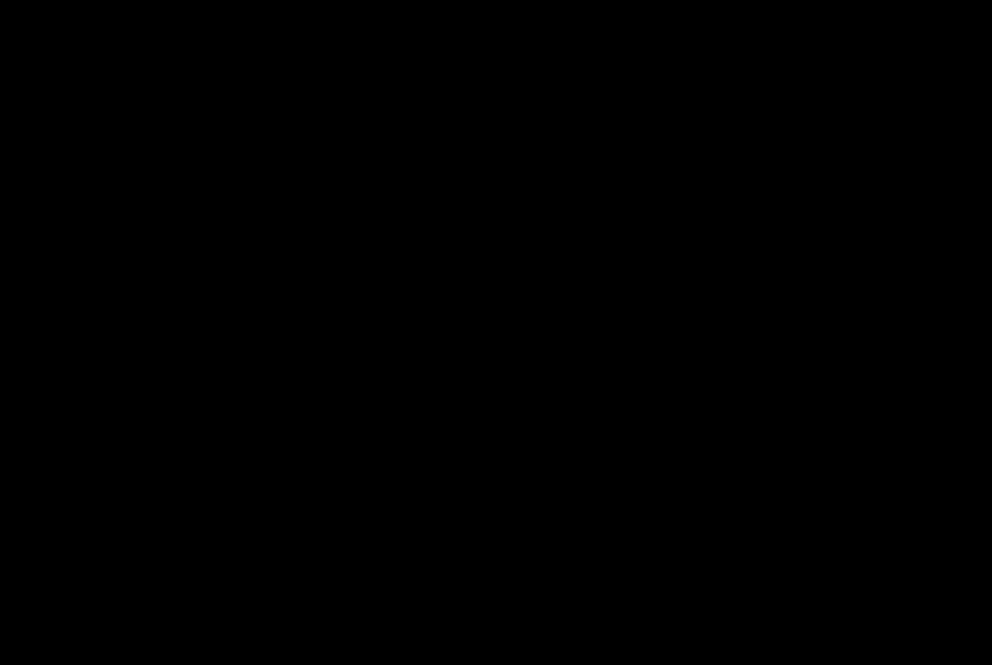

In [350]:
runner = SimulationRunner(
    base_configurations=base_configurations,
    common_parameters=common_parameters
)

# Run all configurations
# initial_states = [[0.05, 0.001, 0.05, 0.001]] * common_parameters['num_particles']

initial_states = None

# initial_states =  [[-0.00381691,  0.00024301,  0.003036,    0.00021282]]


# initial_states = [[ 0.00000000e+00, -1.75842232e-05, -0.00000000e+00, -0.00000000e+00]]

runner.run_configurations(initial_states=initial_states)

# Example of accessing a specific simulator instance for further analysis
# For instance, accessing 'Configuration 1 - With Error'
config_key = 'Configuration 1 - With Error'
if config_key in runner.simulators_with_error:
    simulator = runner.simulators_with_error[config_key]
    # Perform additional analysis or plotting as needed
    # Example: simulator.plot_additional_metrics()
else:
    print(f"{config_key} not found in simulators_with_error.")



In [351]:
sim_no_error = runner.simulators_no_error['Configuration 1 - No Error']
sim_with_error = runner.simulators_with_error['Configuration 1 - With Error']

In [352]:
sim_no_error.bpm_readings['x'].shape

(1, 1, 100)

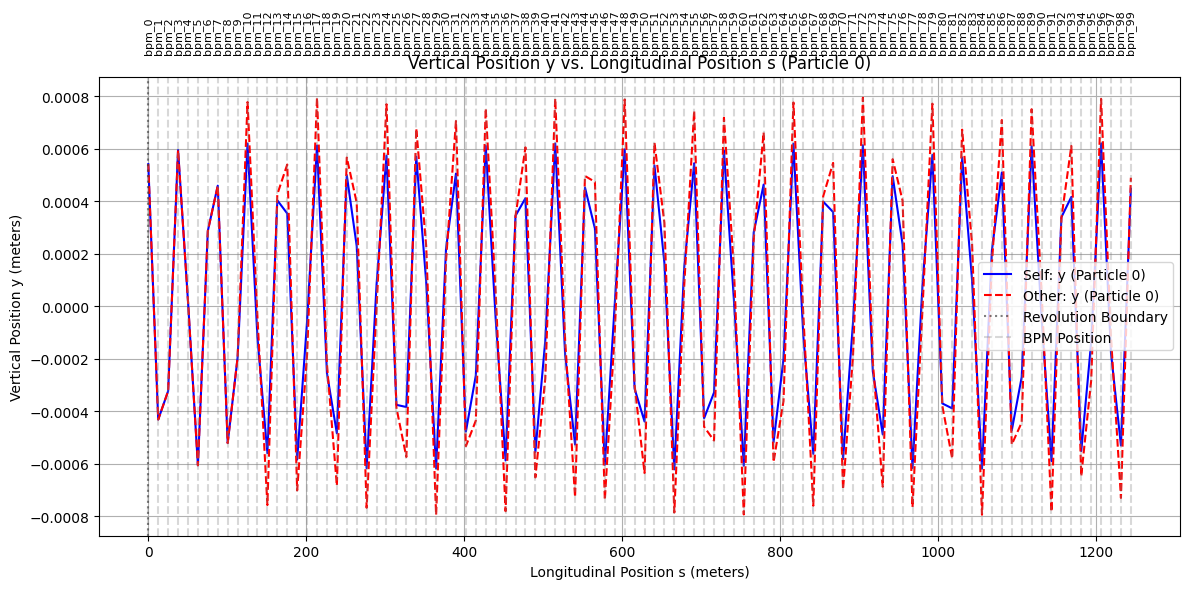

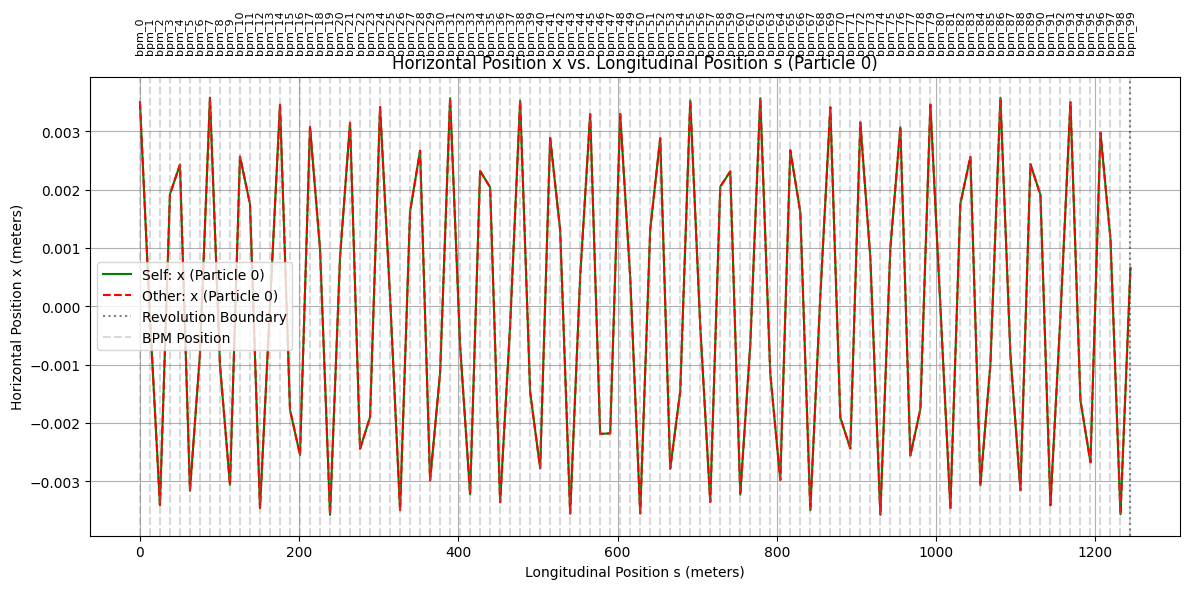

In [353]:
sim_no_error.plot_transverse_vs_longitudinal(particle_idx=0, other_simulator=sim_with_error)

In [43]:
# Extract s-positions for self simulator
s_bpm_self = []
elements_per_cell = {}
for elem in sim_no_error.lattice_elements_positions:
    cell_idx = elem['cell_index']
    if cell_idx not in elements_per_cell:
        elements_per_cell[cell_idx] = []
    elements_per_cell[cell_idx].append(elem)

for cell_idx in sorted(elements_per_cell.keys()):
    last_elem = elements_per_cell[cell_idx][-1]
    s_bpm_self.append(last_elem['end_s'])
s_bpm_self = np.array(s_bpm_self)

# Adjust to start at s=0
s_offset_self = s_bpm_self[0]
s_bpm_self_adjusted = s_bpm_self - s_offset_self
s_values_self = np.tile(s_bpm_self_adjusted, sim_no_error.n_turns)

sim_no_error.bpm_readings['s'] = s_values_self
sim_no_error.bpm_readings['elements_per_cell'] = elements_per_cell


np.save("bpm_readings_10k_revs_no_error", sim_no_error.bpm_readings)

In [44]:
x = np.load("bpm_readings_10k_revs_no_error.npy", allow_pickle=True)
data_dict = x.item()
data_dict.keys()

dict_keys(['x', 'y', 'xp', 'yp', 's', 'elements_per_cell'])

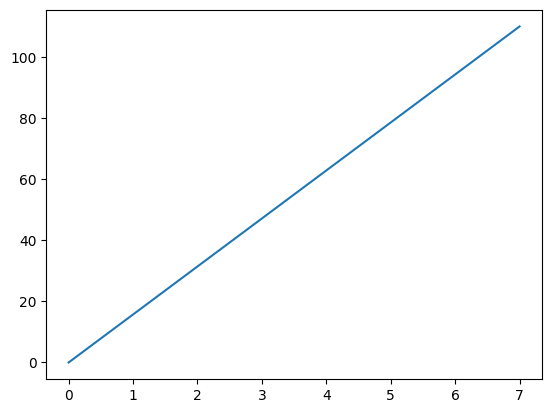

In [45]:
plot(s_values_self[:100])

In [45]:

def get_bpm_s_positions(simulator):
    s_positions = []
    elements_per_cell = {}
    for elem in simulator.lattice_elements_positions:
        cell_idx = elem['cell_index']
        if cell_idx not in elements_per_cell:
            elements_per_cell[cell_idx] = []
        elements_per_cell[cell_idx].append(elem)
    
    # Get the end_s of the last element in each FODO cell
    for cell_idx in sorted(elements_per_cell.keys()):
        last_elem = elements_per_cell[cell_idx][-1]
        s_positions.append(last_elem['end_s'])
    
    return np.array(s_positions)

# Example usage
s_bpm = get_bpm_s_positions(simulator)
circumference = sim_no_error.circumference
n_turns = sim_no_error.n_turns
n_FODO = sim_no_error.n_FODO

# Create s-values for all turns, resetting to 0 at each turn
s_values = []
for turn in range(n_turns):
    s_turn = s_bpm
    s_values.append(s_turn)
s_values = np.concatenate(s_values)

# For continuous plotting with resets, optionally use modulo
# s_values_modulo = s_values % circumference  # Uncomment for wrapped s-values

In [46]:
s_values

array([ 15.70796327,  31.41592654,  47.1238898 , ...,  94.24777961,
       109.95574288, 125.66370614])

In [67]:
np.insert(s_bpm, 0, [0])

array([  0.        ,  15.70796327,  31.41592654,  47.1238898 ,
        62.83185307,  78.53981634,  94.24777961, 109.95574288,
       125.66370614])

In [56]:
n_turns

10

/home/aribra/jnps/thesis/public_repo/lattice_correction_net/synchrotron_simulator_gpu_Dataset_4D.py:2538: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0.03, 1, 0.95])
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


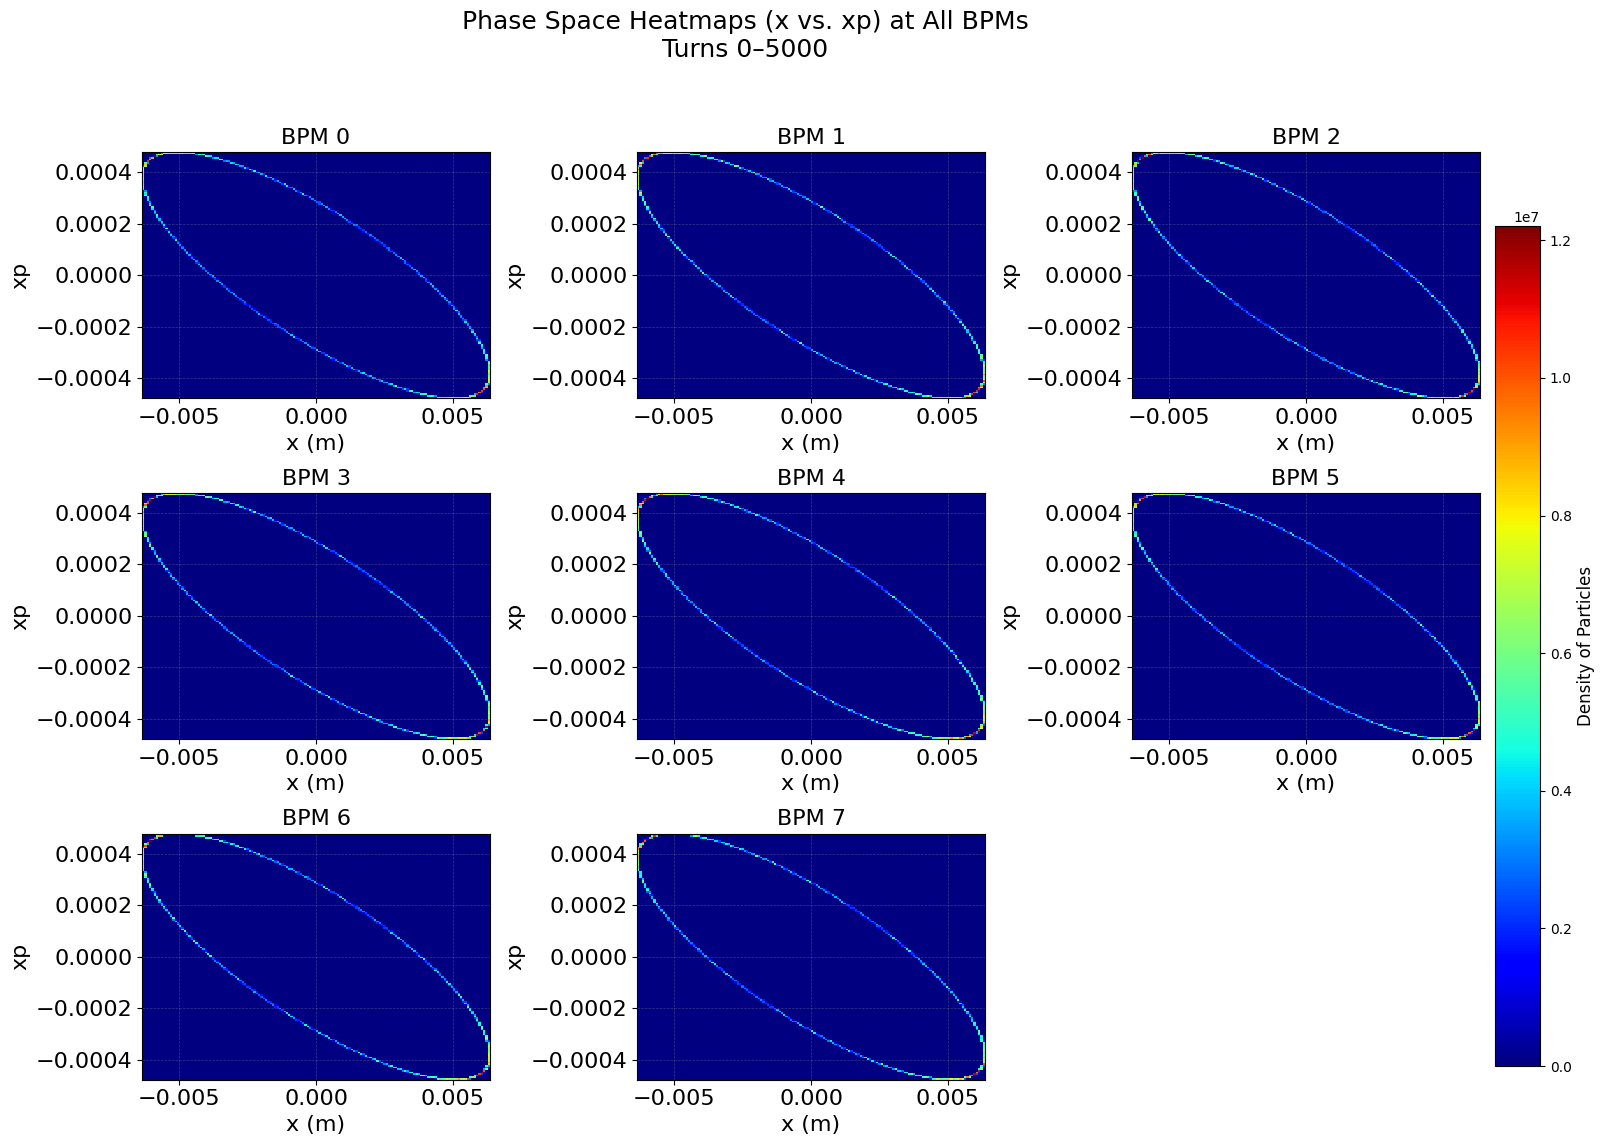

In [25]:
sim_no_error.plot_phase_space_diagram(first_axis='x', second_axis='xp', plot_all=True, start_idx=0, save_label='test_no_error', fontsize=18)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


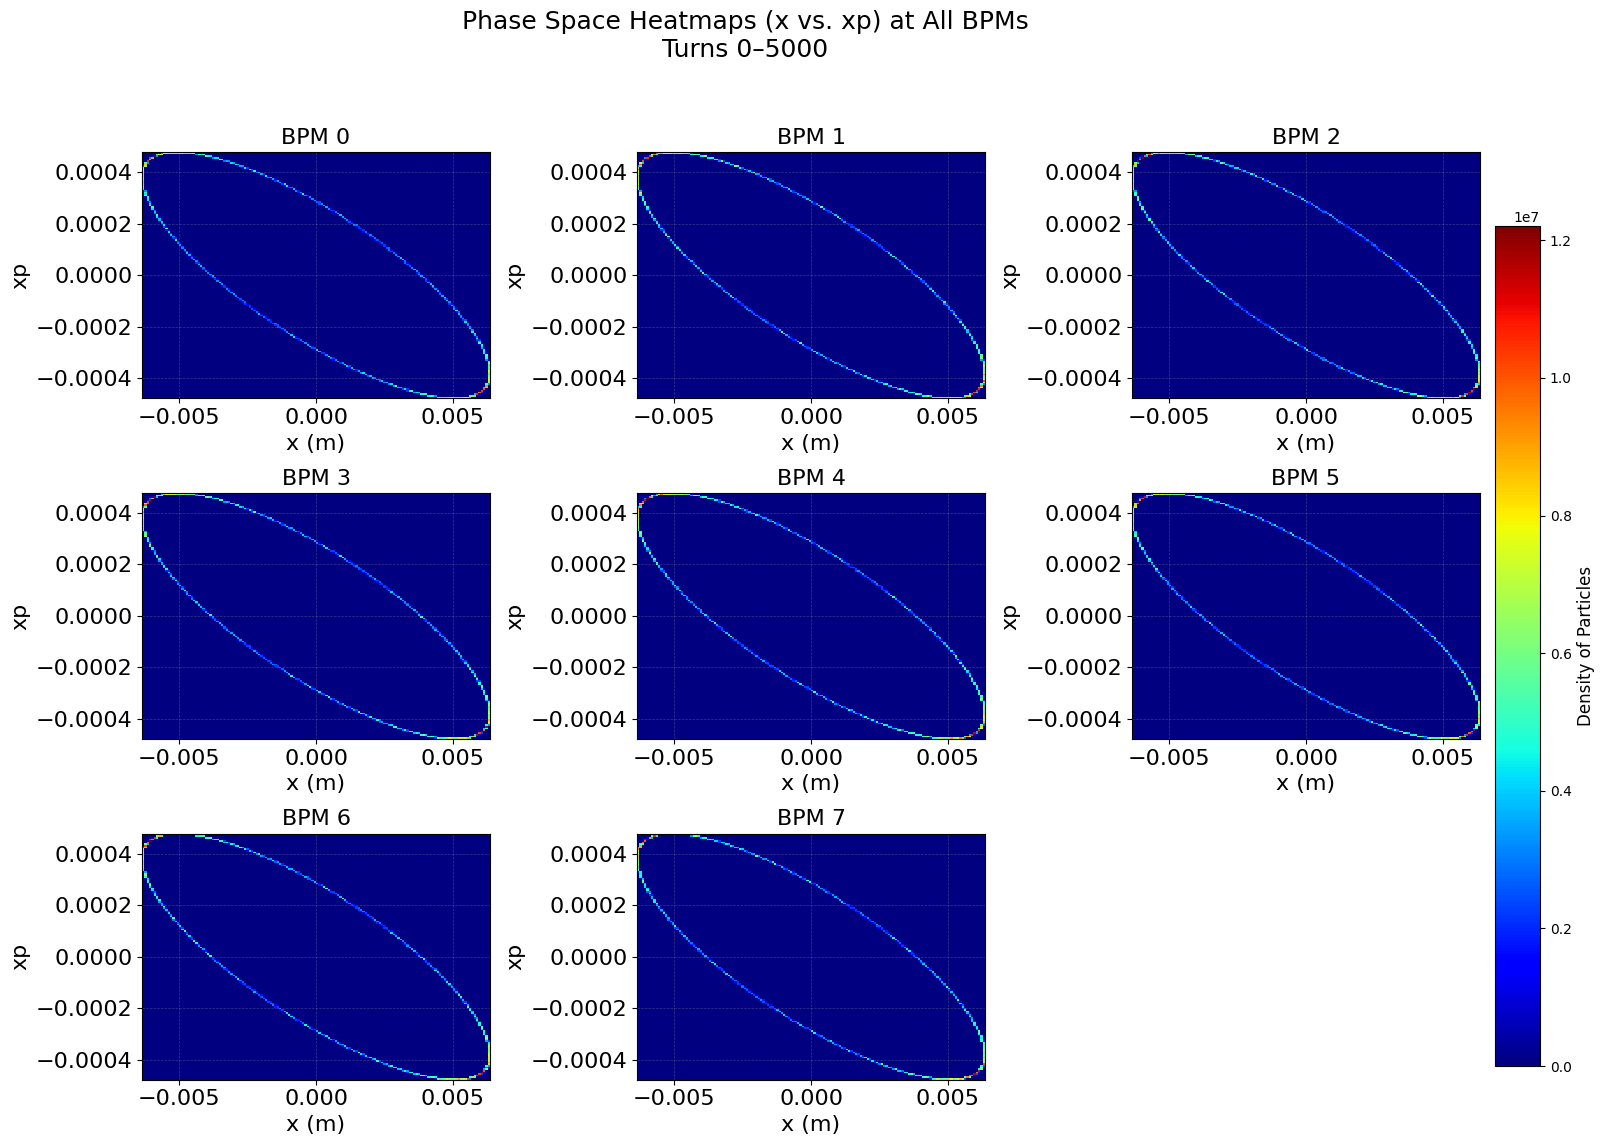

In [26]:
sim_with_error.plot_phase_space_diagram(first_axis='x', second_axis='xp', plot_all=True, start_idx=0 ,save_label='test_with_error', fontsize=18)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


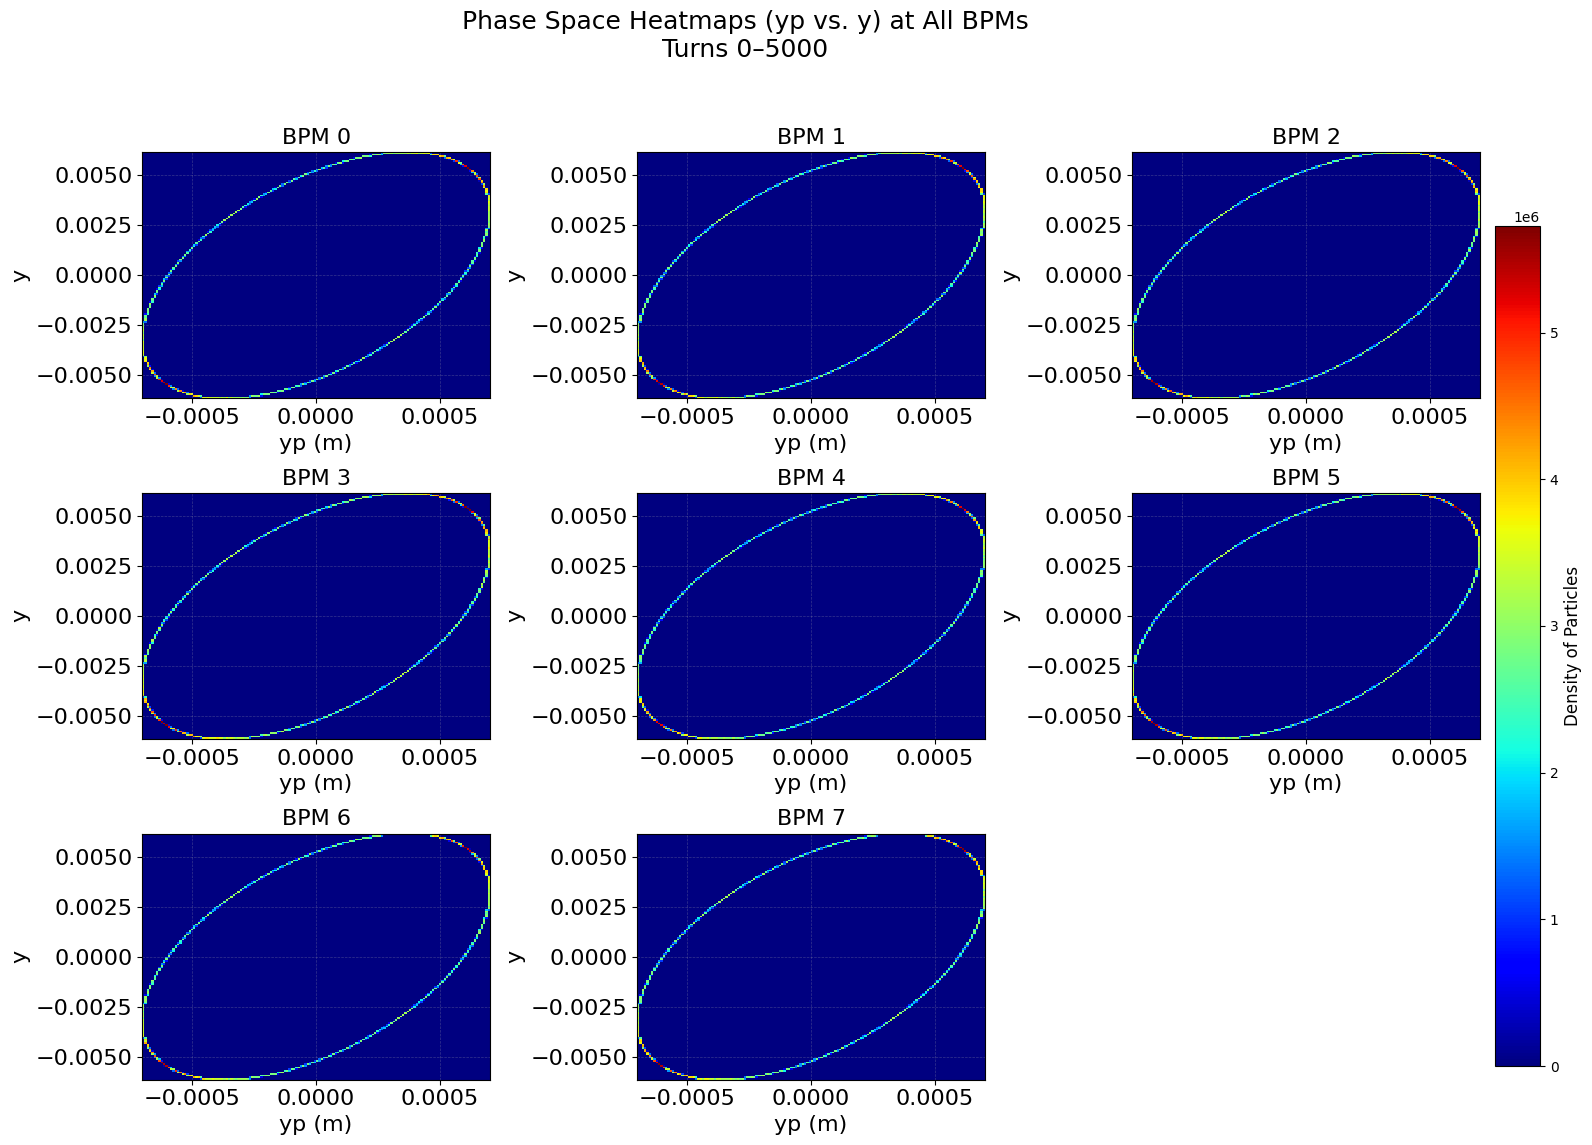

In [27]:
sim_no_error.plot_phase_space_diagram(first_axis='yp', second_axis='y', plot_all=True, start_idx=0, save_label='y_yp_test_no_error', fontsize=18)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


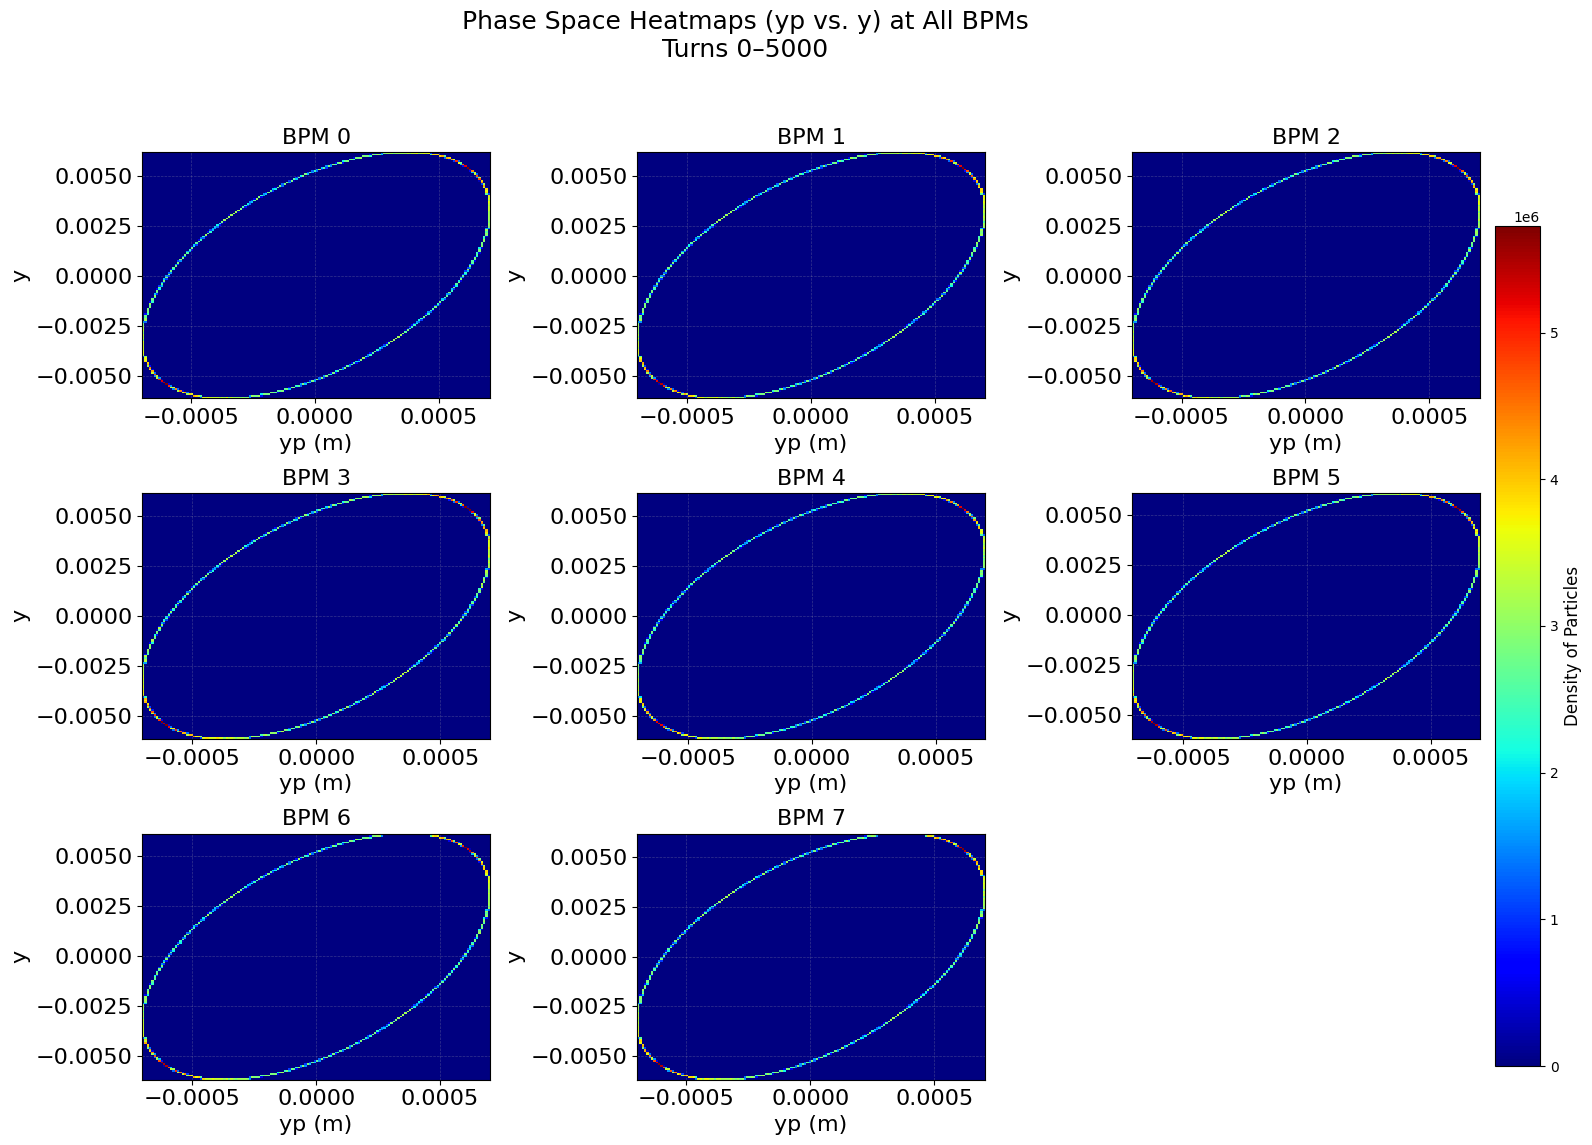

In [28]:
sim_with_error.plot_phase_space_diagram(first_axis='yp', second_axis='y', plot_all=True, start_idx=0 ,save_label='y_yp_test_with_error', fontsize=18)

### FFT

In [47]:
sim_no_error.bpm_readings['x'][0, :, 0]

array([ 0.00437726, -0.00370253,  0.00287631, ...,  0.00517821,
       -0.0052526 ,  0.00511209])

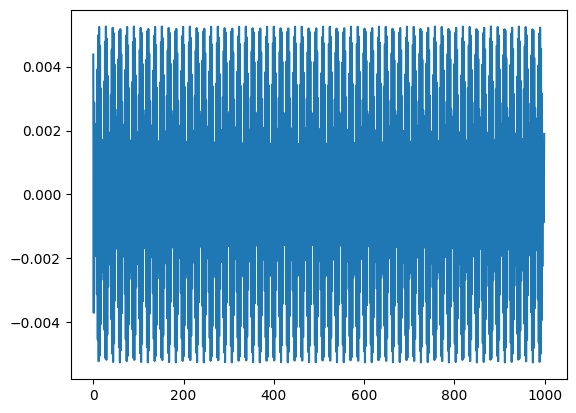

In [48]:
plot(sim_no_error.bpm_readings['x'][0, :1000, 0])

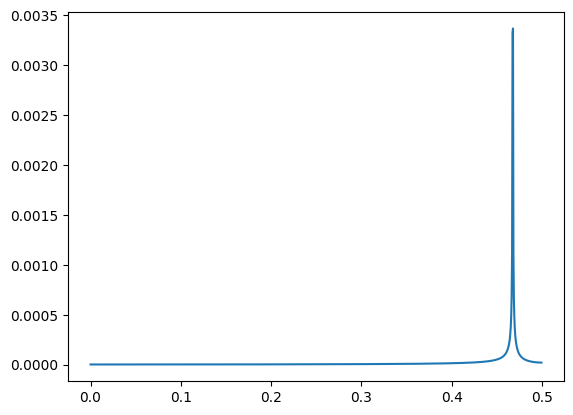

Tune from simulation data: 0.4680


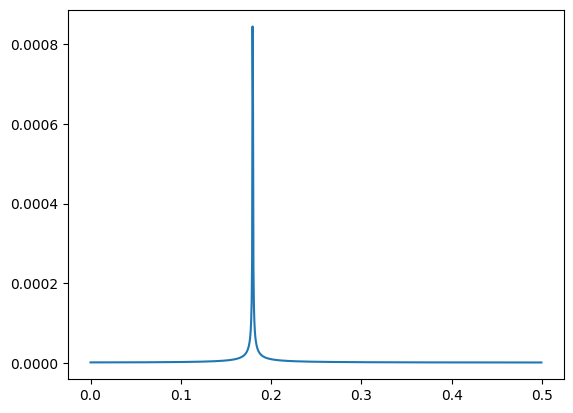

Tune from simulation data: 0.1795


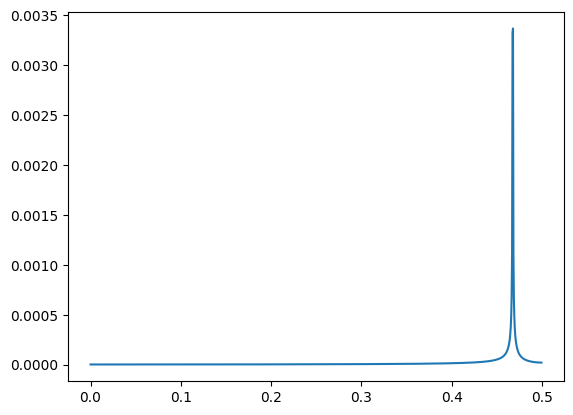

Tune from simulation data: 0.4680


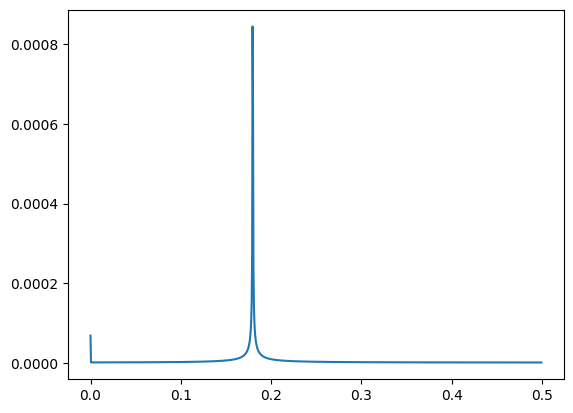

Tune from simulation data: 0.1795


In [49]:
from scipy.fft import fft, fftfreq
from scipy.signal import find_peaks

def tune_from_fft(data):
    # Step 2: Perform FFT on the uniformly sampled data
    N = len(data)  # Number of samples
    T = 1  # Sampling interval
    yf = fft(data)  # FFT of y
    xf = fftfreq(N, T)[:N//2]  # Corresponding frequency bins
    
    plt.figure()
    plt.plot(xf, 2.0/N * np.abs(yf[:N//2]), label='FFT of y(x)')
    # plt.plot(xf, 2.0/N * np.abs(yf[:N//2]), label='FFT of y(x)')
    plt.show()
    
    
    
    # Assume xf and yf are already defined
    # xf: Frequency values
    # yf: FFT values (complex)
    
    # Compute the magnitude spectrum
    magnitude = 2.0 / N * np.abs(yf[:N//2])  # Ensure magnitude is for positive frequencies
    
    # Find peaks in the magnitude spectrum
    # peaks, _ = find_peaks(magnitude, height=0.0001)  # Adjust height threshold as needed
    peaks, _ = find_peaks(magnitude)  # Adjust height threshold as needed
    peak_frequencies = xf[peaks]
    peak_magnitudes = magnitude[peaks]
    
    # Print the peak frequencies and magnitudes
    for freq, mag in zip(peak_frequencies, peak_magnitudes):
        print(f"Tune from simulation data: {freq:.4f}")


tune_x_from_fft = tune_from_fft(sim_no_error.bpm_readings['x'][0, :2000, 0])
tune_y_from_fft = tune_from_fft(sim_no_error.bpm_readings['y'][0, :2000, 0])

tune_x_from_fft = tune_from_fft(sim_with_error.bpm_readings['x'][0, :2000, 0])
tune_y_from_fft = tune_from_fft(sim_with_error.bpm_readings['y'][0, :2000, 0])



In [50]:
np.save("bpm_readings_10k_revs", sim_no_error.bpm_readings)

In [51]:
x = np.load("bpm_readings_10k_revs.npy", allow_pickle=True)
data_dict = x.item()
data_dict.keys()

dict_keys(['x', 'y', 'xp', 'yp', 's'])

In [52]:
! pwd


/home/aribra/jnps/thesis/public_repo/lattice_correction_net/notebooks


In [54]:
data_dict['x'].shape

(1, 10000, 8)

In [62]:
data_dict['s']

0.0

### Twiss parameters

In [33]:
alpha_x, beta_x, epsilon_x, alpha_y, beta_y, epsilon_y = sim_no_error.compute_twiss_parameters()

In [34]:
print(f'alpha_x: {alpha_x}, beta_x: {beta_x}, epsilon_x: {epsilon_x}, \n alpha_y: {alpha_y}, beta_y: {beta_y}, epsilon_y: {epsilon_y}')

alpha_x: 1.3231539413736924, beta_x: 22.070265557828495, epsilon_x: 0.12463539894276571, 
 alpha_y: -0.6182915394144198, beta_y: 10.313129893916766, epsilon_y: 0.13403151535275418


In [146]:
peaks

array([], dtype=int64)

In [45]:
sim_with_error.figs_save_dir

'figs'

In [46]:
sim_no_error.n_turns

5

In [47]:
4 * 4

16

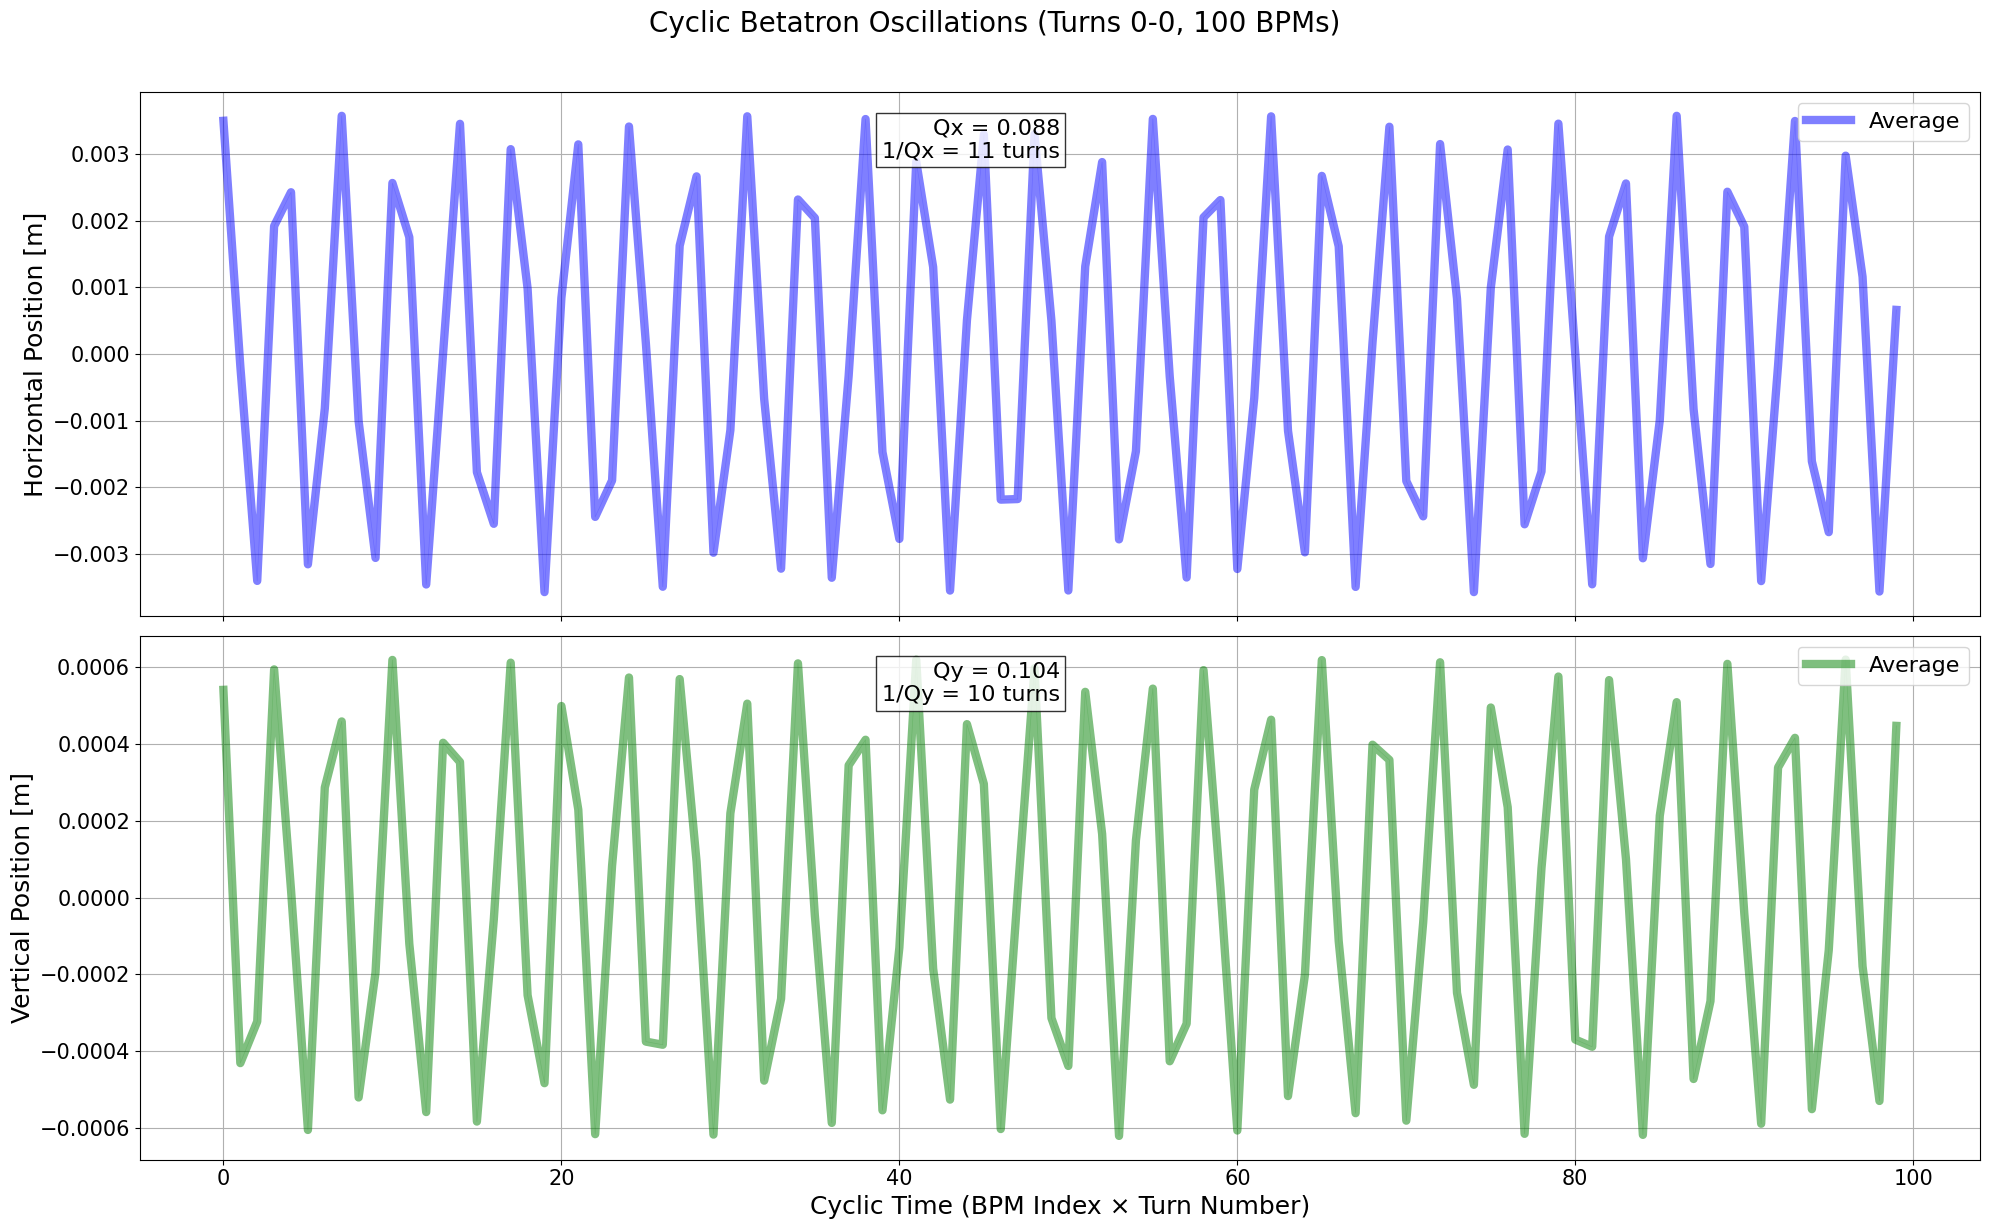

In [354]:
sim_no_error.plot_betatron_oscillations_TURN_FLATTEN(
    n_particles=100,
    start_turn=0, 
    end_turn=10,
    save_label='no_error',
)


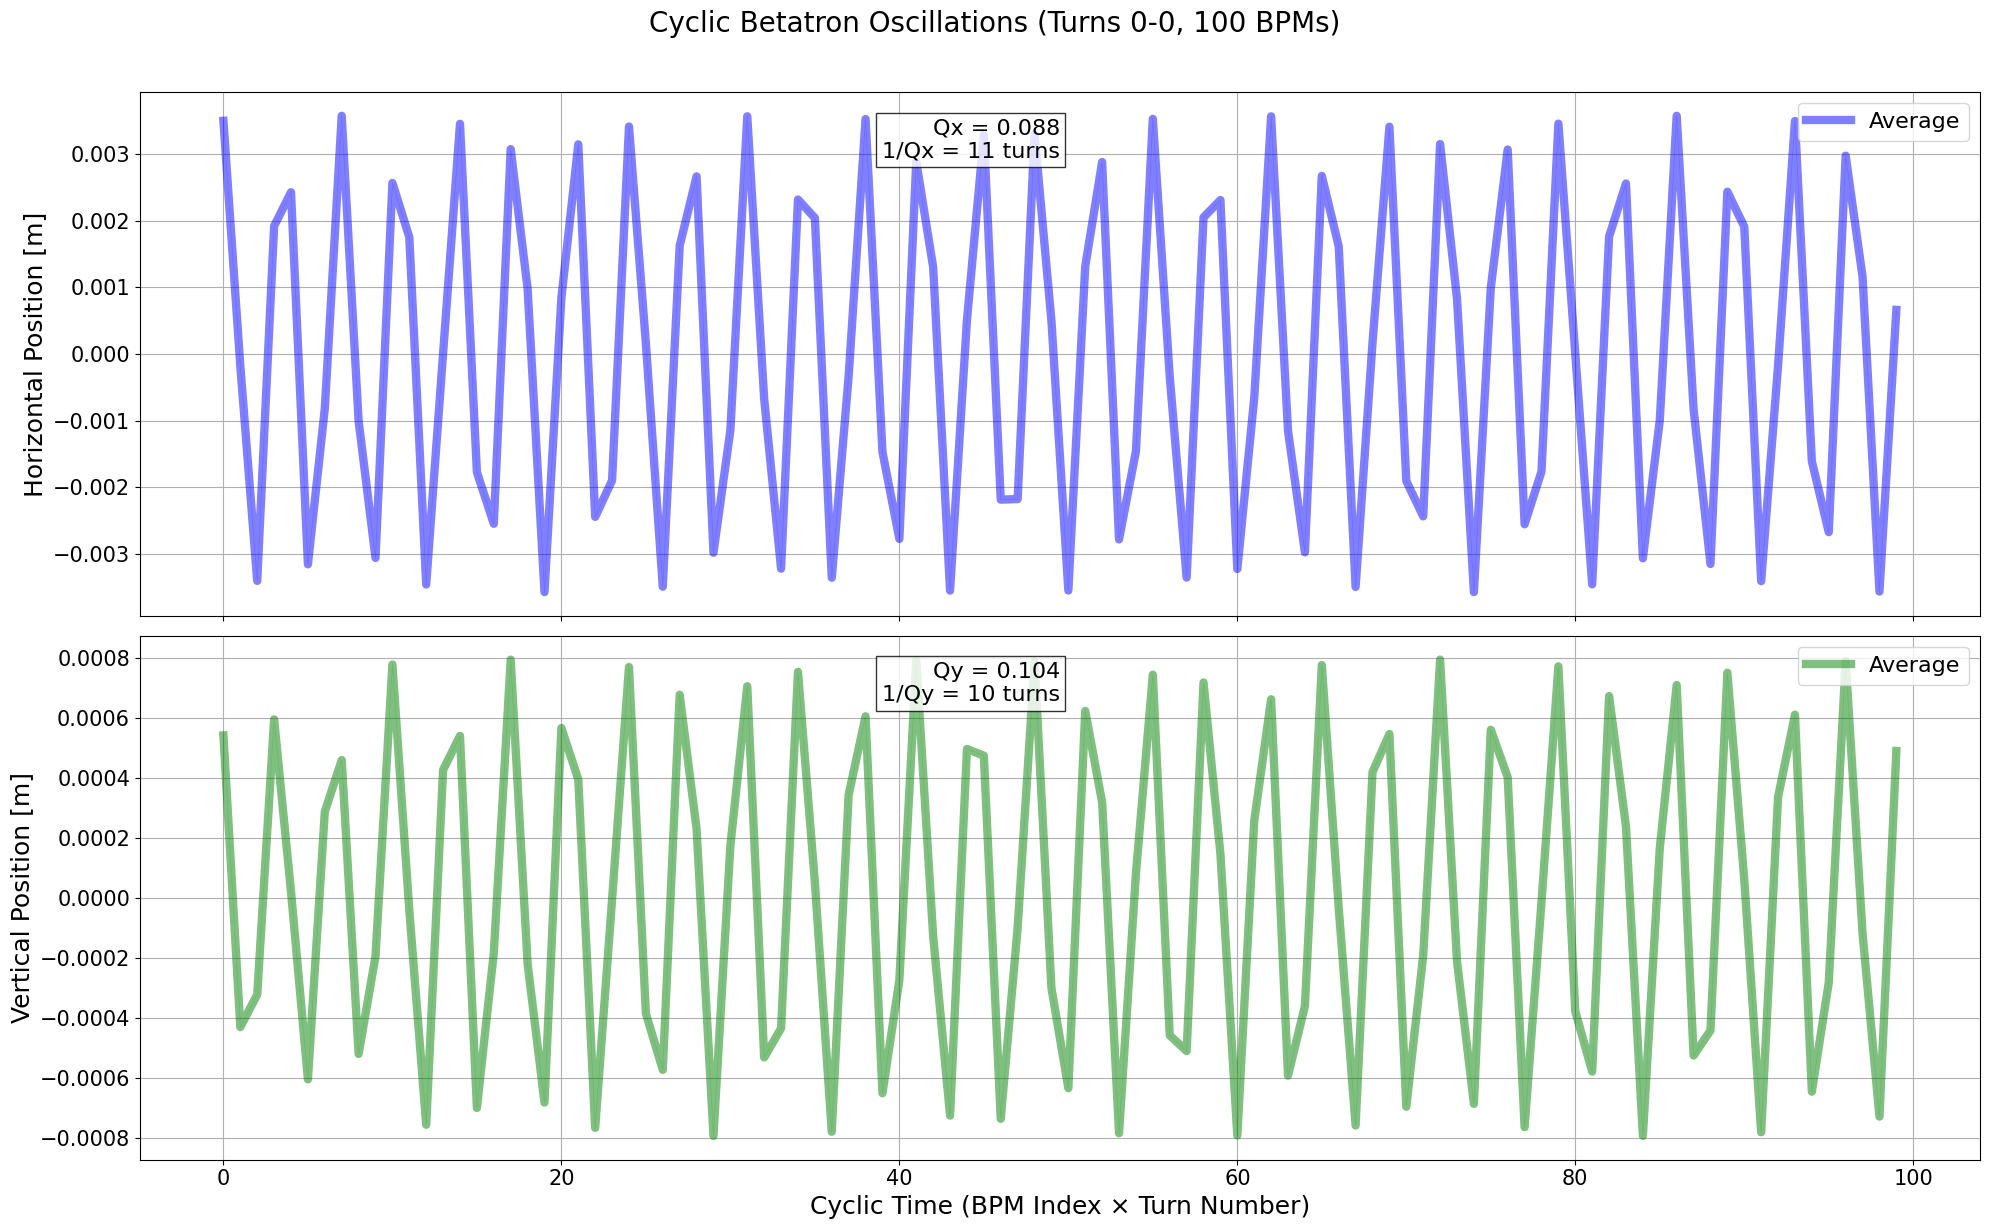

In [355]:
sim_with_error.plot_betatron_oscillations_TURN_FLATTEN(
    n_particles=100,
    start_turn=0, 
    end_turn=10,
    save_label='with_error',
)


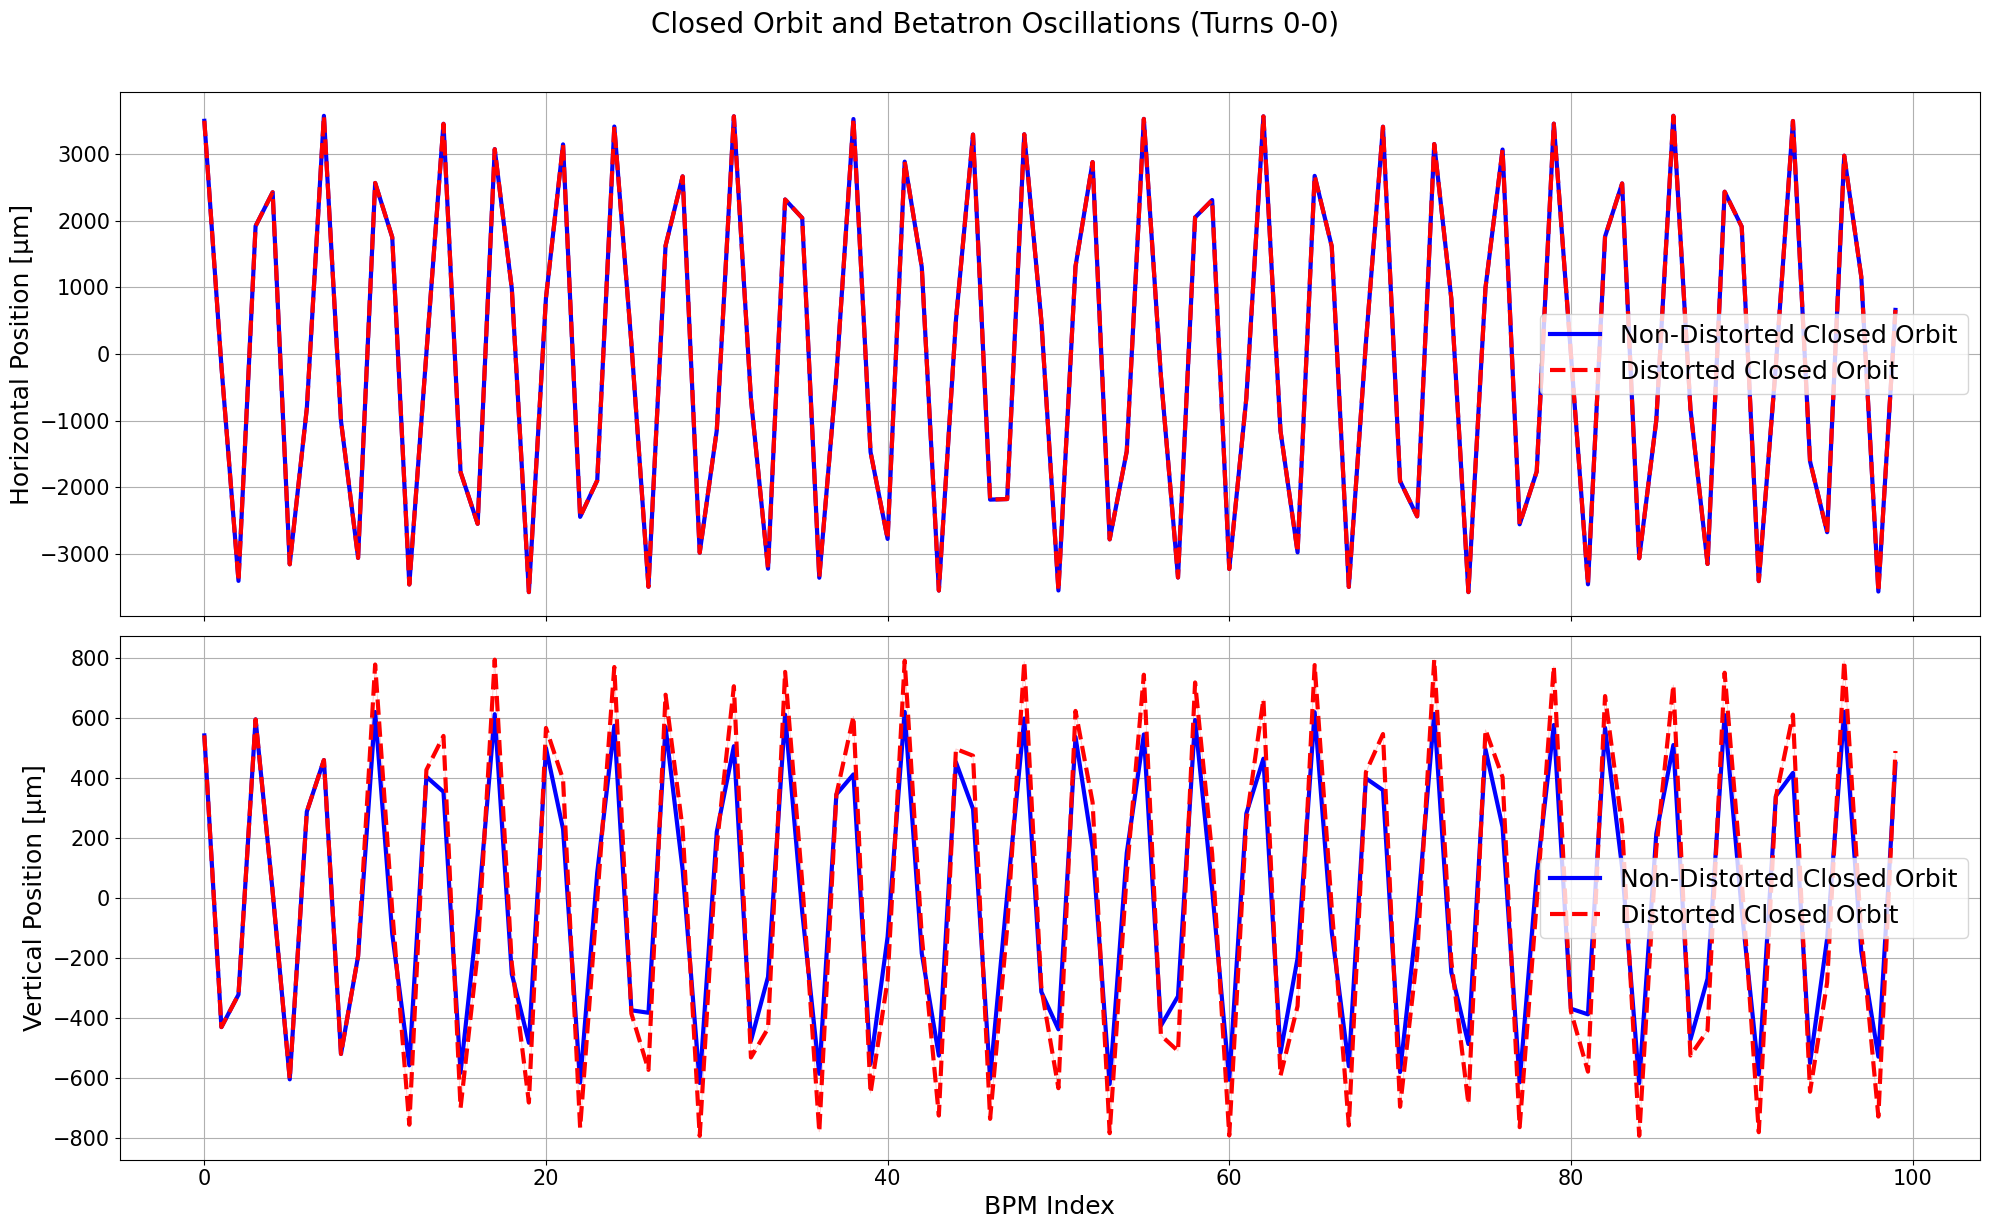

In [356]:
sim_no_error.plot_betatron_oscillations_BPM(
    sim_with_error,
    n_particles=1,
    start_turn=0, 
    end_turn=1000,
    save_label='comparison',
)


plot_comparison() - BPM 0/
	 CoM No error: X = 0.00048211074130224746, Y = -0.00023103014724313166
	 CoM With Error: X = 0.00048211074130224746, Y = -0.00020642094391735586
----
	 ΔX = 0.0000000 m, 0.00 micron
	 ΔY = 0.0000246 m, 24.61 micron
	 beam epsilon X = 0.0044984 m, 4498.36 micron
	 beam epsilon Y = 0.0043539 m, 4353.92 micron
----
plot_comparison() - BPM 1/
	 CoM No error: X = -0.00019364057124836775, Y = -0.004293723555946536
	 CoM With Error: X = -0.00019364057124836775, Y = -0.004257634106909313
----
	 ΔX = 0.0000000 m, 0.00 micron
	 ΔY = 0.0000361 m, 36.09 micron
	 beam epsilon X = 0.0044984 m, 4498.36 micron
	 beam epsilon Y = 0.0043539 m, 4353.92 micron
----
plot_comparison() - BPM 2/
	 CoM No error: X = -0.0006393304239028668, Y = -0.004926557388209434
	 CoM With Error: X = -0.0006393304239028668, Y = -0.004890467939172207
----
	 ΔX = 0.0000000 m, 0.00 micron
	 ΔY = 0.0000361 m, 36.09 micron
	 beam epsilon X = 0.0044984 m, 4498.36 micron
	 beam epsilon Y = 0.0043539 m, 

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


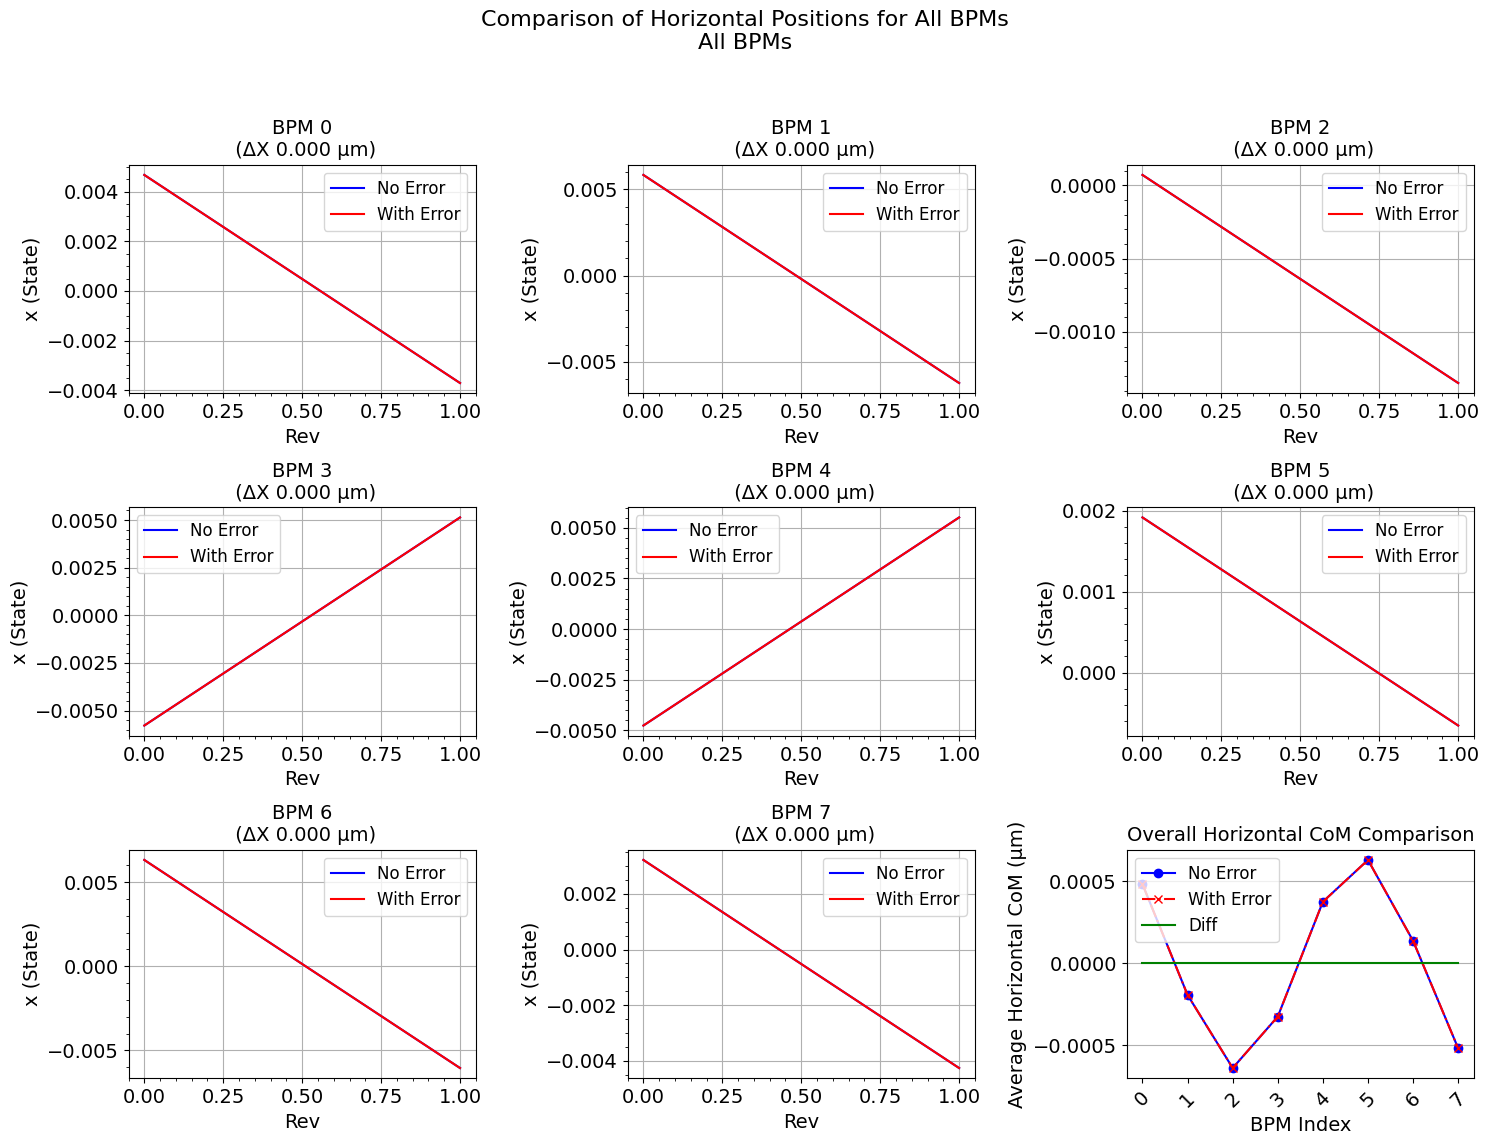

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


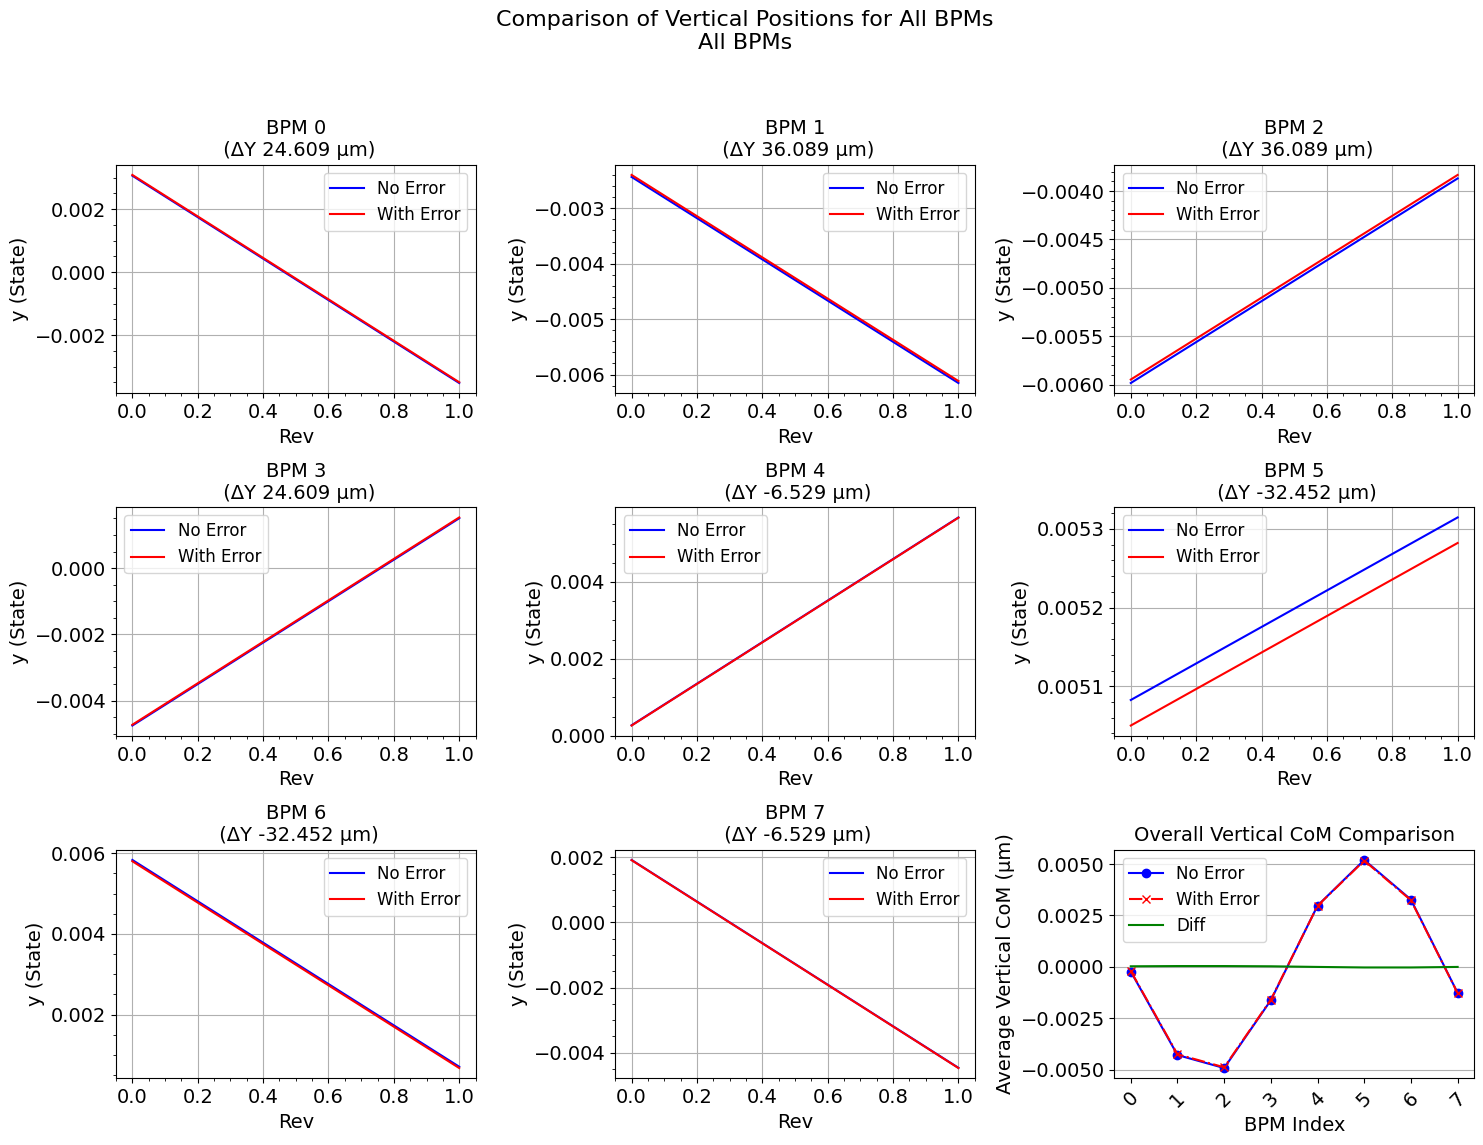

In [43]:

sim_no_error.plot_comparison(
    sim_with_error, 
    cell_idx=2, 
    start_idx=0, 
    end_idx=2,
    viz_start_idx=0,
    viz_end_idx=2, 
    save_label="sim_test", 
    window_size=1, 
    plot_all=True, 
    extra_title="All BPMs")


In [21]:
-1.75842232e-05

-1.75842232e-05

In [22]:
0.5949649+0.80375168j

(0.5949649+0.80375168j)

In [23]:
 [[ 3.32244410e-01, -6.33731995e+00, -1.01349045e-17,  4.47729428e-17],
 [ 5.70374284e-02,  1.92188506e+00,  1.43910248e-17, -6.38588592e-17],
 [-3.12002922e-18,  4.13583235e-17,  7.37394901e-01, -3.85271430e+00],
 [ 5.41646199e-18, -7.27206950e-17,  4.37603267e-01, -9.30248316e-01]]

[[0.33224441, -6.33731995, -1.01349045e-17, 4.47729428e-17],
 [0.0570374284, 1.92188506, 1.43910248e-17, -6.38588592e-17],
 [-3.12002922e-18, 4.13583235e-17, 0.737394901, -3.8527143],
 [5.41646199e-18, -7.2720695e-17, 0.437603267, -0.930248316]]

In [ ]:
7.37394901e-01

In [ ]:
-1.75842232e-05

  Quadrupole Tilt Error 1: FODO Cell 3, Defocusing, Tilt Angle = np.pi/2 rad (90 degrees)


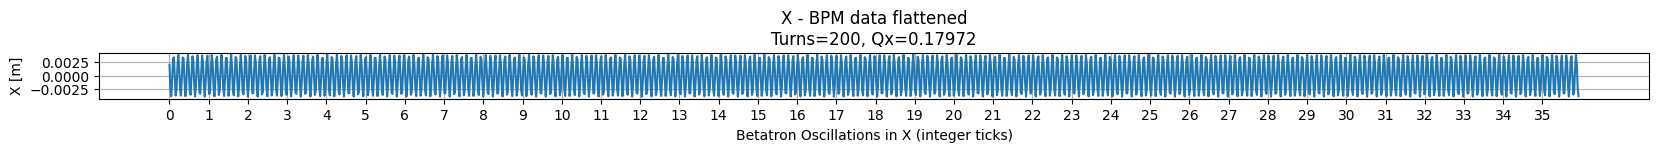

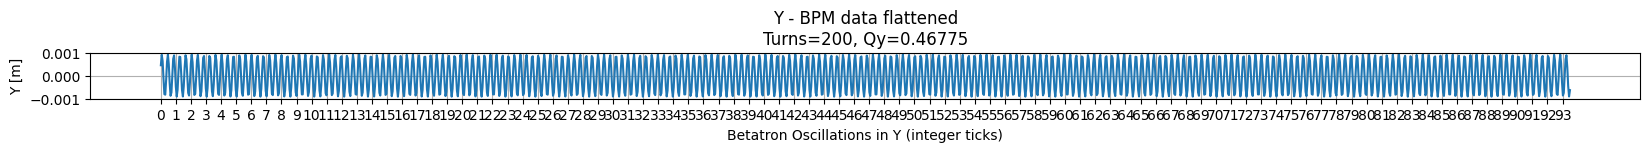

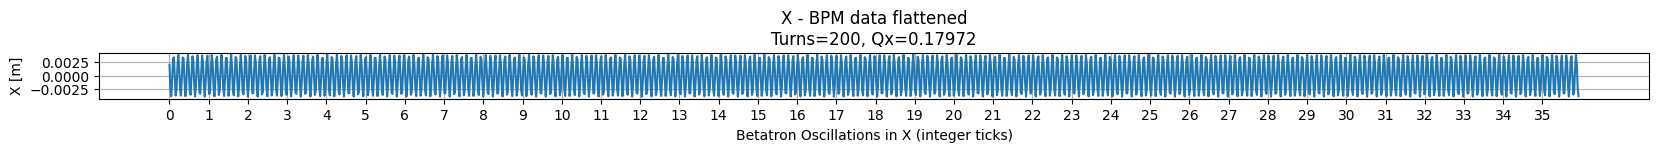

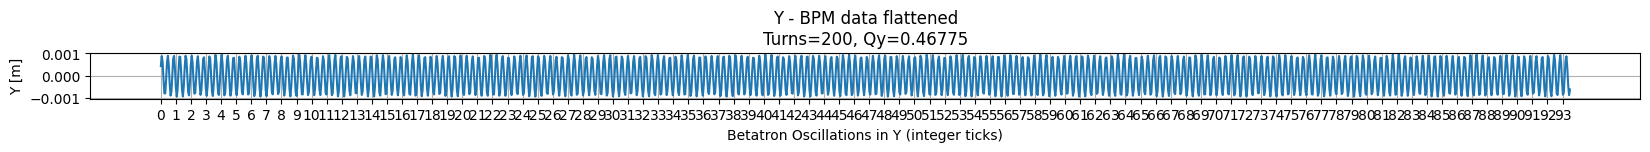

In [48]:
particle_idx = 0
start_idx = 4000
end_idx = 4200


print("  Quadrupole Tilt Error 1: FODO Cell 3, Defocusing, Tilt Angle = np.pi/2 rad (90 degrees)")
sim_no_error.plot_particle_bpm_readings(particle_idx, start_idx, end_idx)
sim_with_error.plot_particle_bpm_readings(particle_idx, start_idx, end_idx)

  Quadrupole Tilt Error 1: FODO Cell 3, Defocusing, Tilt Angle = -0.5235987755982988 rad (30 degrees)


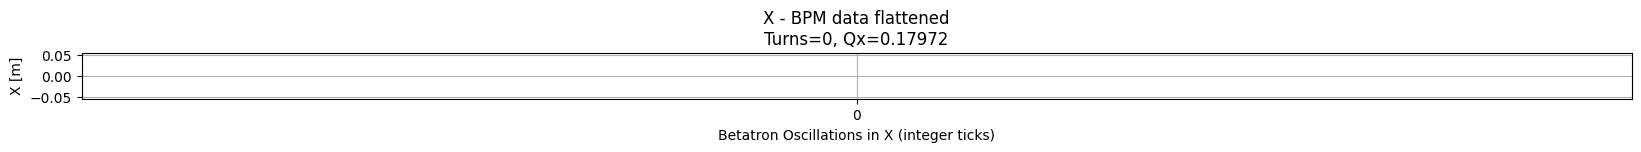

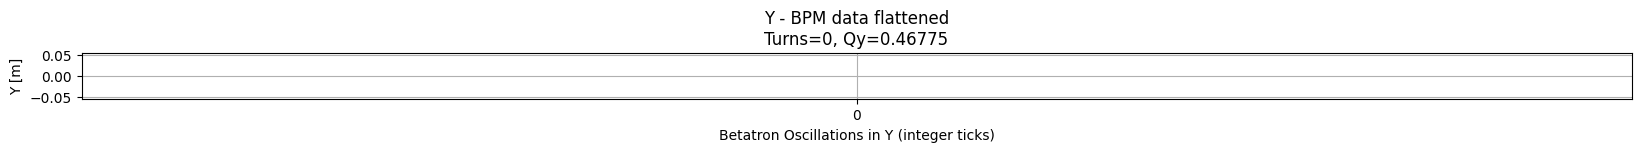

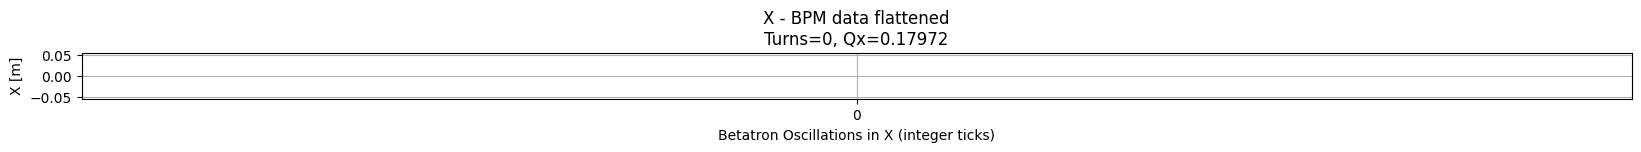

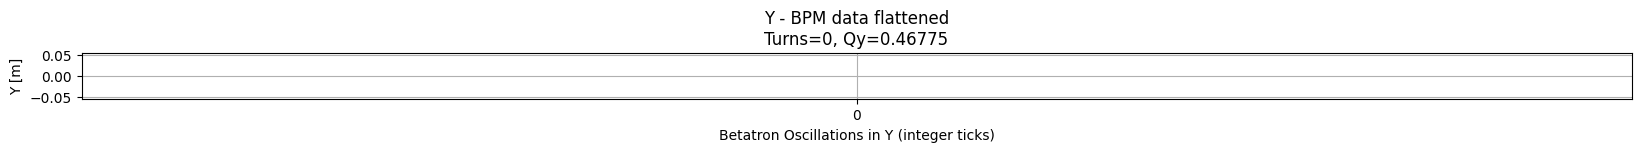

In [46]:
particle_idx = 0
start_idx = 7000
end_idx = 8000


print("  Quadrupole Tilt Error 1: FODO Cell 3, Defocusing, Tilt Angle = -0.5235987755982988 rad (30 degrees)")
sim_no_error.plot_particle_bpm_readings(particle_idx, start_idx, end_idx)
sim_with_error.plot_particle_bpm_readings(particle_idx, start_idx, end_idx)

In [ ]:
viz_end_idx = sim_no_error.n_turns
sim_no_error.plot_comparison(sim_with_error, cell_idx=0, viz_start_idx=viz_end_idx - 200,
                     viz_end_idx=viz_end_idx, save_label="sim_test", window_size=50, plot_all=True, extra_title="All BPMs")

In [ ]:
sim_no_error.plot_phase_space_diagram(first_axis='x', second_axis='y', cell_idx=4, plot_all=False)

In [ ]:
sim_no_error.plot_phase_space_diagram(first_axis='x', second_axis='xp', cell_idx=i, plot_all=True)

In [ ]:
sim_no_error.plot_phase_space_diagram(first_axis='y', second_axis='yp', cell_idx=i, plot_all=True)

In [ ]:
sim_with_error.plot_phase_space_diagram(first_axis='x', second_axis='xp', cell_idx=i, plot_all=True)

In [ ]:
sim_with_error.plot_phase_space_diagram(first_axis='y', second_axis='yp', cell_idx=i, plot_all=True)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


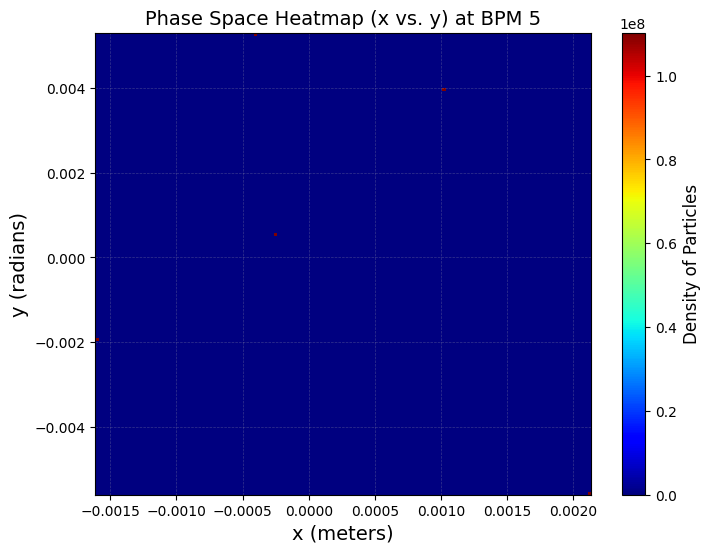

In [53]:
sim_no_error.plot_phase_space_diagram(first_axis='x', second_axis='y', cell_idx=5)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


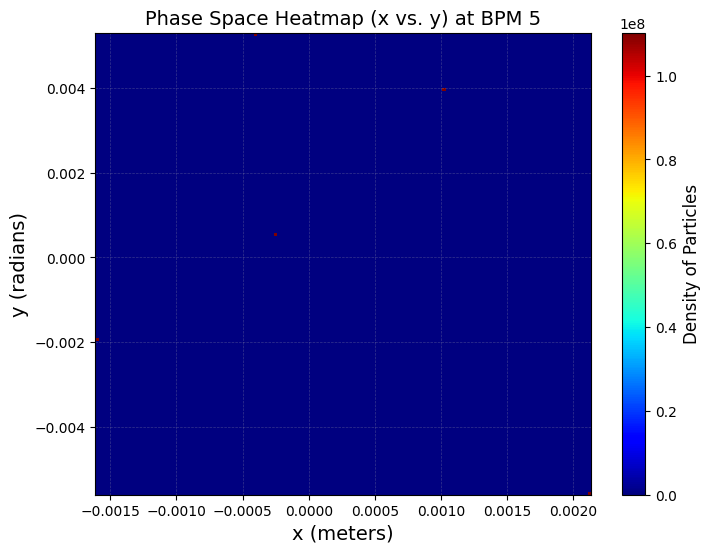

In [55]:
sim_with_error.plot_phase_space_diagram(first_axis='x', second_axis='y', cell_idx=5)

In [ ]:
sim_with_error.plot_phase_space_diagram(first_axis='xp', second_axis='x', cell_idx=0)

In [54]:
sim_no_error.compare_bpm_signal_vs_bpm_number(
    other_simulator=sim_with_error,
    turn=99,
    plane='vertical',
    average_over_particles=True,
    plot_difference=True
)


ValueError: Requested turn 99 is out of range for at least one simulator.

plot_bpm_comparison_last_images()/
	 CoM No error: X = 4.7575821931943504e-07, Y = -3.441036754224712e-07
	 CoM With Error: X = 4.7575821931943504e-07, Y = -3.441036754224712e-07
----
	 f'ΔX = 0.0000000 m, 0.00 micron
	 f'ΔY = 0.0000000 m, 0.00 micron
----


/home/aribra/jnps/thesis/public_repo/lattice_correction_net/synchrotron_simulator_gpu_Dataset_4D.py:2318: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  legend = plt.legend(facecolor='gray', edgecolor='white', framealpha=0.7)
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


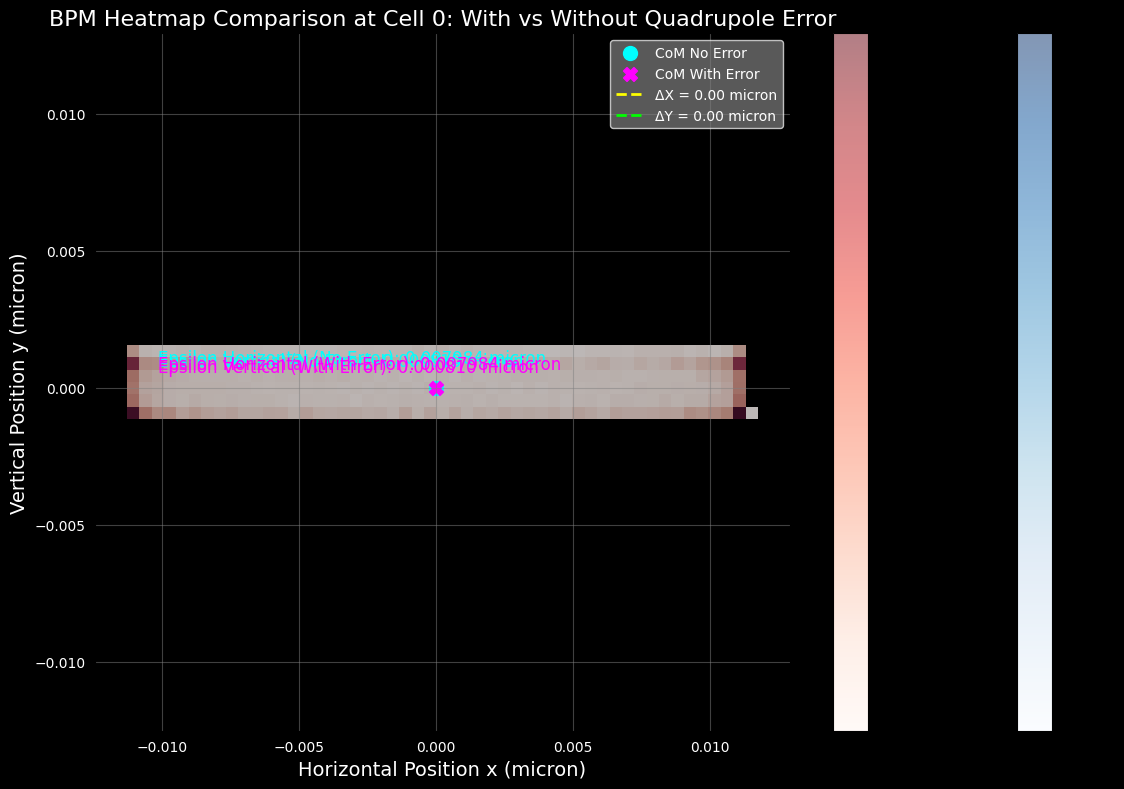

AttributeError: 'SynchrotronSimulator' object has no attribute 'plot_comparison'

In [97]:
cell_idx = 0
sim_no_error.plot_bpm_comparison_last_images(sim_no_error, sim_with_error, cell_idx=cell_idx, particles='all_mean')
viz_start_idx = sim_no_error.n_turns - 100
viz_end_idx = sim_no_error.n_turns
sim_no_error.plot_comparison(sim_with_error, cell_idx=cell_idx, viz_start_idx=viz_start_idx, viz_end_idx=viz_end_idx)

In [ ]:
cell_idx = 0
sim_no_error.plot_bpm_comparison_last_images(sim_no_error, sim_with_error, cell_idx=cell_idx, particles='all_mean')
viz_start_idx = sim_no_error.n_turns - 100
viz_end_idx = sim_no_error.n_turns
sim_no_error.plot_comparison(sim_with_error, cell_idx=cell_idx, viz_start_idx=viz_start_idx, viz_end_idx=viz_end_idx)

In [57]:

total_elements_no_error = len(sim_no_error.M_lattice_4x4)
total_elements_with_error = len(sim_with_error.M_lattice_4x4)

total_elements_no_error, total_elements_with_error

(64, 64)

In [58]:
sim_no_error.M_lattice_4x4[12]

array([[1.       , 0.7817477, 0.       , 0.       ],
       [0.       , 1.       , 0.       , 0.       ],
       [0.       , 0.       , 1.       , 0.7817477],
       [0.       , 0.       , 0.       , 1.       ]])

In [59]:
sim_with_error.M_lattice_4x4[13]

array([[ 0.95694034,  5.80569355,  0.        ,  0.        ],
       [-0.01451423,  0.95694034,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  1.        ,  5.89048623],
       [ 0.        ,  0.        ,  0.        ,  1.        ]])

In [60]:
sim_no_error.n_turns

5

In [61]:
sim_no_error.bpm_readings['x'].shape

(1, 5, 8)

In [62]:
# sim_no_error.bpm_readings['x']

In [63]:
ix = 0

In [98]:
sim_no_error.bpm_readings['y'][:, :, bpm_ix]

array([[-0.00113007, -0.00065041,  0.00057414, ..., -0.00111838,
        -0.00025541,  0.00090007]])

NameError: name 'ix' is not defined

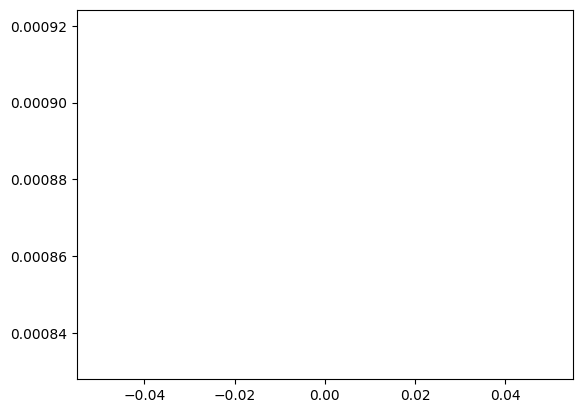

In [44]:
bpm_ix = 0

plt.plot(sim_no_error.bpm_readings['y'][:, 0, bpm_ix].flatten())
plt.plot(sim_no_error.bpm_readings['y'][:, ix, bpm_ix].flatten())
plt.show()
plt.plot(sim_no_error.bpm_readings['x'][:, 0, bpm_ix].flatten(), sim_no_error.bpm_readings['y'][:, 0, bpm_ix].flatten(), '.')
plt.plot(sim_no_error.bpm_readings['x'][:, ix, bpm_ix].flatten(), sim_no_error.bpm_readings['y'][:, ix, bpm_ix].flatten(), '.')
plt.show()
ix+=1

/home/aribra/jnps/thesis/public_repo/lattice_correction_net/synchrotron_simulator_gpu_Dataset_4D.py:2082: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


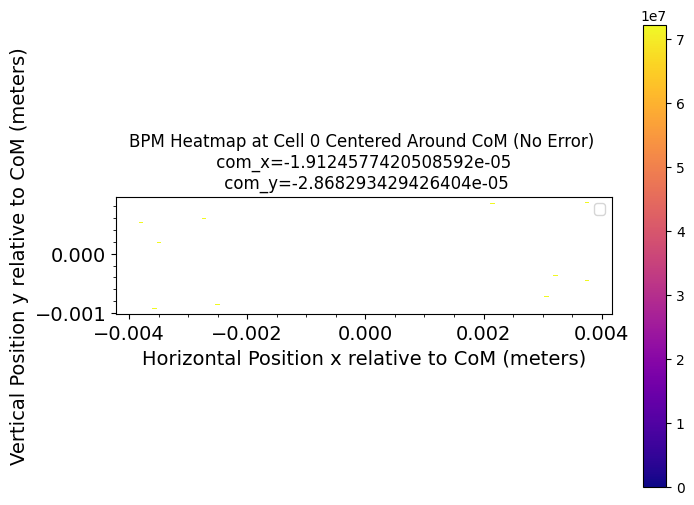

/home/aribra/jnps/thesis/public_repo/lattice_correction_net/synchrotron_simulator_gpu_Dataset_4D.py:2082: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


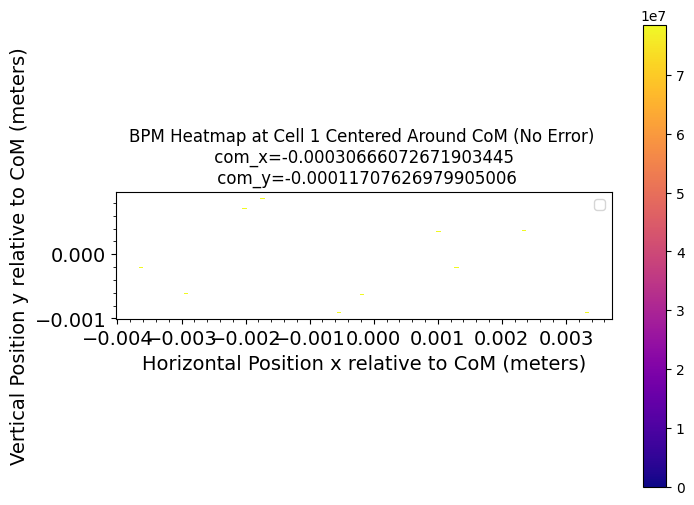

/home/aribra/jnps/thesis/public_repo/lattice_correction_net/synchrotron_simulator_gpu_Dataset_4D.py:2082: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


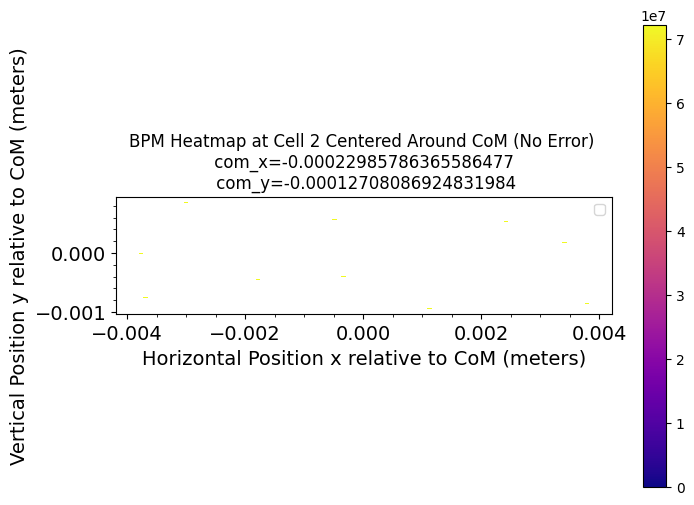

/home/aribra/jnps/thesis/public_repo/lattice_correction_net/synchrotron_simulator_gpu_Dataset_4D.py:2082: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


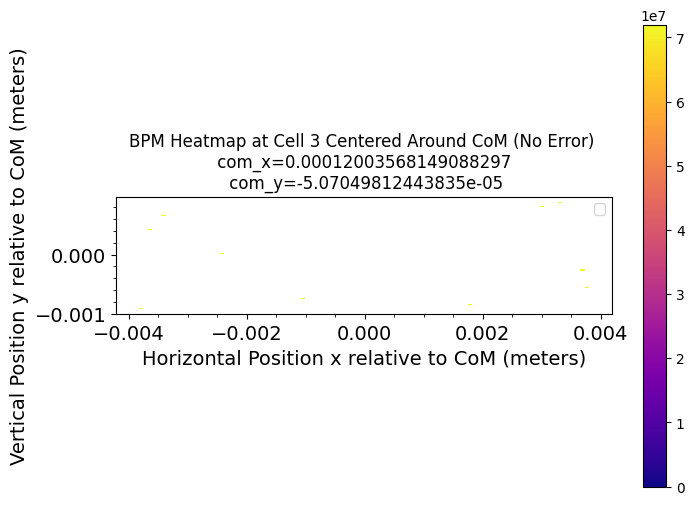

/home/aribra/jnps/thesis/public_repo/lattice_correction_net/synchrotron_simulator_gpu_Dataset_4D.py:2082: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


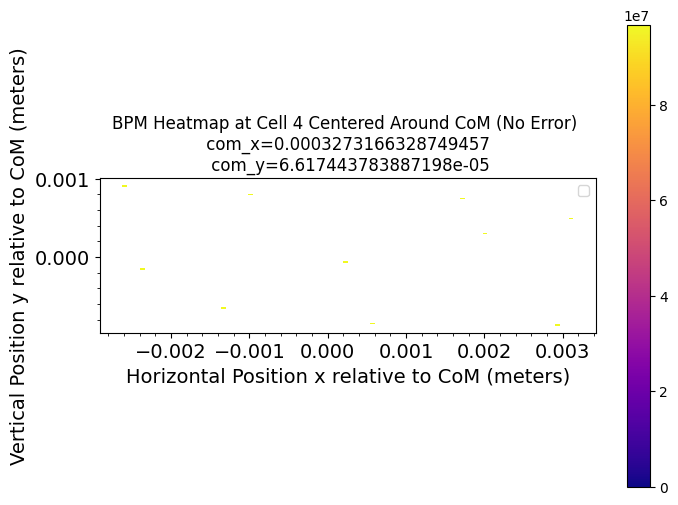

/home/aribra/jnps/thesis/public_repo/lattice_correction_net/synchrotron_simulator_gpu_Dataset_4D.py:2082: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


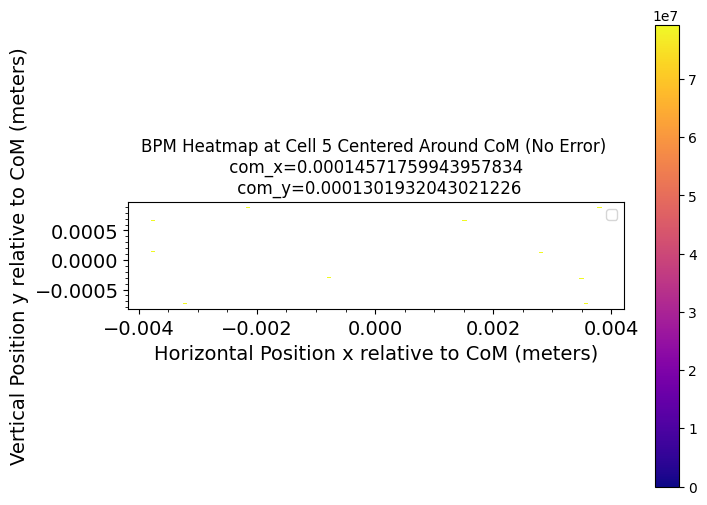

/home/aribra/jnps/thesis/public_repo/lattice_correction_net/synchrotron_simulator_gpu_Dataset_4D.py:2082: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


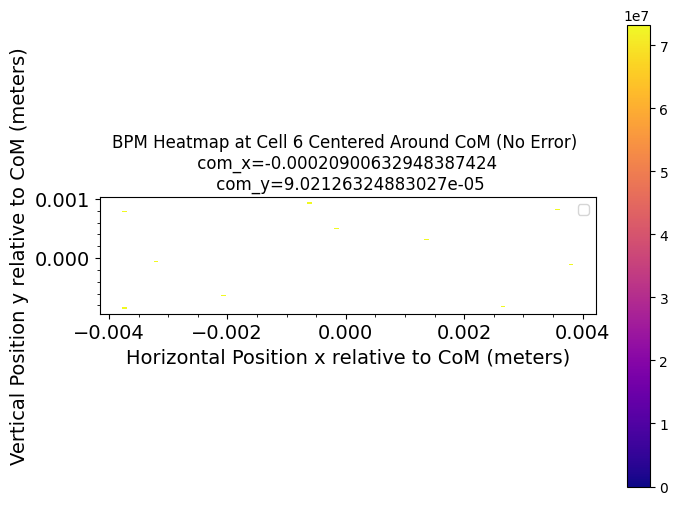

/home/aribra/jnps/thesis/public_repo/lattice_correction_net/synchrotron_simulator_gpu_Dataset_4D.py:2082: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


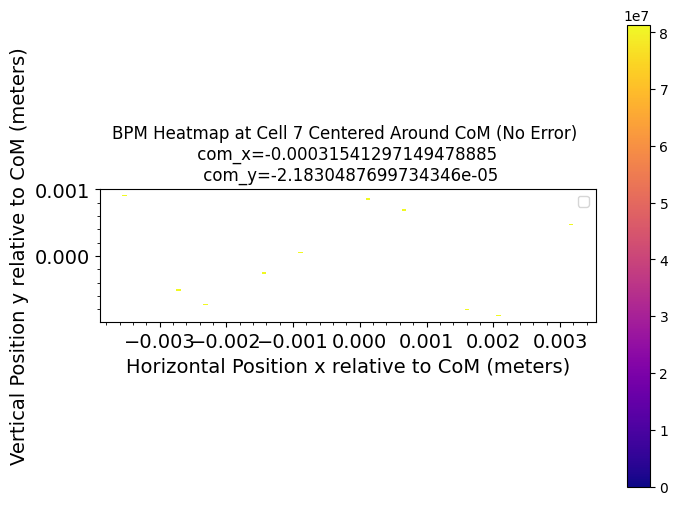

In [43]:
xy_lim = 0.2
plot_xlim = (-xy_lim, xy_lim)
plot_ylim = (-xy_lim, xy_lim)

plot_xlim = None
plot_ylim = None

for i in range(sim_no_error.n_FODO):
    sim_with_error.plot_bpm_heatmaps(
        cell_idx=i, 
        simulation_label='No Error', 
        start_idx=0, 
        end_idx=10,
        plot_xlim=plot_xlim, 
        plot_ylim=plot_ylim)


In [ ]:
from IPython.display import clear_output


xy_lim = 0.1
plot_xlim = (-xy_lim, xy_lim)
plot_ylim = (-xy_lim, xy_lim)

plot_xlim = None
plot_ylim = None

cell_idx = 1
start_idx = 0
for i in range(2):
    sim_with_error.plot_bpm_heatmaps(
        cell_idx=cell_idx, 
        simulation_label='No Error', 
        start_idx=start_idx, 
        end_idx=start_idx+i+1,
        plot_xlim=plot_xlim, 
        plot_ylim=plot_ylim)
    
    clear_output(wait=True)


In [ ]:
sim_no_error.n_turns

In [ ]:
xy_lim = 0.1
plot_xlim = (-xy_lim, xy_lim)
plot_ylim = (-xy_lim, xy_lim)

plot_xlim = None
plot_ylim = None

for i in range(sim_no_error.n_FODO):
    sim_no_error.plot_bpm_heatmaps(
        cell_idx=i, 
        simulation_label='No Error', 
        start_idx=0, 
        end_idx=1500,
        plot_xlim=plot_xlim, 
        plot_ylim=plot_ylim)


In [ ]:
for i in range(sim_no_error.n_FODO):
    particle_idx_start = 0
    particle_idx_end = 10
    start_idx = 0
    end_idx = -1
    cell_idx = i
    

    x_data = sim_no_error.bpm_readings['x'][particle_idx_start:particle_idx_end, start_idx:end_idx, cell_idx]
    xp_data = sim_no_error.bpm_readings['xp'][particle_idx_start:particle_idx_end, start_idx:end_idx, cell_idx]
    
    # x - x'
    plt.figure(figsize=(8,6))
    plt.scatter(x_data, xp_data, alpha=0.7)
    plt.xlabel('x (meters)')
    plt.ylabel("x' (radians)")
    plt.title(f'Phase Space Diagram at BPM {cell_idx}')
    plt.grid(True)
    plt.show()

In [ ]:
particle_idx = 0
start_idx = 1900
end_idx = 2000

sim_no_error.plot_particle_bpm_readings(particle_idx, start_idx, end_idx)

In [ ]:
1 / sim_no_error.Qx

In [ ]:
sim_no_error.n_turns

In [ ]:
xy_lim = 0.005
plot_xlim = (-xy_lim, xy_lim)
plot_ylim = (-xy_lim, xy_lim)

# plot_xlim = None
# plot_ylim = None

sim_no_error.plot_all_bpm_heatmap(start_idx=0, end_idx=-1, plot_ylim=plot_ylim, plot_xlim=plot_xlim)

In [ ]:
help(sim_no_error.plot_all_bpm_heatmap)

In [ ]:
# xy_lim = 0.1
# plot_xlim = (-xy_lim, xy_lim)
# plot_ylim = (-xy_lim, xy_lim)

# # plot_xlim = None
# # plot_ylim = None

# for i in range(sim_with_error.n_FODO):
#     sim_with_error.plot_bpm_heatmaps(cell_idx=i, simulation_label='With Error', plot_xlim=plot_xlim, plot_ylim=plot_ylim)


In [ ]:
# sim_with_error.plot_average_positions()

In [ ]:
for i in range(sim_no_error.n_FODO):
    sim_no_error.plot_last_bpm_image(cell_idx=i)

In [ ]:
# args: plot_xlim=(15, 17), plot_ylim=(-10, -12)
plot_xlim = (-22, -18)
plot_ylim = (5, -5)

# plot_xlim = None
# plot_ylim = None

fig, ax = sim_no_error.plot_particle_trajectory(start_idx=0, end_idx=5, plot_xlim=plot_xlim, plot_ylim=plot_ylim)

In [ ]:
# plot_xlim = (-6, -7)
# plot_ylim = (-15, -10.5)

plot_xlim = None
plot_ylim = None

fig, ax = sim_no_error.plot_particle_trajectory(start_idx=1, end_idx=10, plot_xlim=plot_xlim, plot_ylim=plot_ylim)

### Generate Datasets

In [ ]:
# # Parameters for generate_data
# 'start_rev': 0,
# 'end_rev': 500,
# 'fodo_cell_indices': list(range(8)),  # Indices of BPMs to consider
# 'planes': ['x', 'y'],
# 'cell_idx': 0,
# 'max_revolutions': 100

In [101]:
sim_no_error.bpm_readings['y'].shape

(1, 5000, 8)

In [102]:
simulation_dataset = SimulationDataset(
    bpm_readings_no_error=sim_no_error.bpm_readings,
    bpm_readings_with_error=sim_with_error.bpm_readings,
    bpm_positions=sim_no_error.bpm_positions,
    quadrupole_errors=sim_with_error.quad_errors,
    lattice_reference=sim_no_error.get_lattice_reference()
)

input_tensor, target_tensor = simulation_dataset.generate_data(
    1000, 1500, [7], ['x', 'y']
)

TypeError: SimulationDataset.__init__() missing 3 required positional arguments: 'merged_config', 'quadrupole_tilt_errors', and 'dipole_tilt_errors'

In [103]:
input_tensor.shape

NameError: name 'input_tensor' is not defined

In [104]:
input_tensor[0, :, 0, 0, np.newaxis].shape
# plot(input_tensor[0, :, 0, 0, np.newaxis])

NameError: name 'input_tensor' is not defined

In [105]:
np.concatenate([running_average_numpy(input_tensor[0, :, 0, 0], 100)[..., np.newaxis], running_average_numpy(input_tensor[0, :, 0, 0], 100)[..., np.newaxis]], axis=-1).shape

NameError: name 'running_average_numpy' is not defined

In [ ]:
target_tensor

In [ ]:
def running_average_numpy(data, window_size):
    data = np.asarray(data)
    if window_size <= 0:
        raise ValueError("Window size must be positive.")
    if window_size > len(data):
        raise ValueError("Window size cannot be larger than the data length.")

    # Use 'valid' mode to ensure the window fits completely within the data
    window = np.ones(window_size) / window_size
    running_avg = np.convolve(data, window, mode='valid')
    return running_avg

In [ ]:
plot(sim_no_error.bpm_readings['x'][0, -10:, 0])
plot(sim_with_error.bpm_readings['x'][0, -10:, 0])


In [ ]:
cumu_y = sim_no_error.cumulative_average(input_tensor[0, :, 0, 1])
ravg_y = running_average_numpy(input_tensor[0, :, 0, 1], window_size=100)
plot(input_tensor[0, 0:, 0, 1])
plot(cumu_y[0:])
plot(ravg_y[0:])

show()

plot(ravg_y[-100:])
plot(cumu_y[-100:])
# plot(input_tensor[0, -5:, 0, 1])
legend(['ravg_y', 'cumu_y'])

In [ ]:
cumu_y = sim_no_error.cumulative_average(input_tensor[0, :, 0, 1])
ravg_y = running_average_numpy(input_tensor[0, :, 0, 1], window_size=1500)
plot(input_tensor[0, 1000:, 0, 1])
plot(cumu_y[1000:])
plot(ravg_y[1000:])

show()

plot(ravg_y[-100:])
plot(cumu_y[-100:])
# plot(input_tensor[0, -5:, 0, 1])
legend(['ravg_y', 'cumu_y'])

In [ ]:
plot(ravg_y[-100:])

In [ ]:
plot(cumu_y[-1900:])
plot(cumu_y[-1400:])

In [ ]:
ravg_y.shape

In [ ]:
plot(cumu_y[1000:])
# plot(ravg_y[1000:])

In [ ]:
plot(ravg_y[-100:])
plot(cumu_y[-100:])
# plot(input_tensor[0, -5:, 0, 1])
legend(['ravg_y', 'cumu_y'])

In [ ]:
# sim_with_error.plot_ring()

In [ ]:
sim_no_error.plot_comparison(sim_with_error, cell_idx=0)

In [ ]:
sim_no_error.plot_comparison(sim_with_error, cell_idx=0, viz_start_idx=0, viz_end_idx=1000)

In [ ]:
sim_no_error.bpm_readings['x'].shape

In [ ]:
self_y_cumu_avg_no_error = sim_no_error.cumulative_average(sim_no_error.overall_avg_y_positions)
other_y_cumu_avg_w_error = sim_no_error.cumulative_average(sim_with_error.overall_avg_y_positions)

In [ ]:
# def cumulative_average(arr, axis=-1):
#     if type(arr) == list:
#         arr = np.array(arr)
#     cumsum = np.cumsum(arr, axis=axis)
#     print(f"cumsum.shape={cumsum.shape}")
    
#     # Create a denominator array for cumulative averages
#     shape = np.ones(len(arr.shape), dtype=int)  # Create a shape of all ones
#     shape[axis] = arr.shape[axis]               # Set the correct dimension along the specified axis
#     denom = np.arange(1, arr.shape[axis] + 1).reshape(shape)  # Reshape to match the axis dimension

#     cumavg = cumsum / denom  # Broadcast division
#     return cumavg


In [ ]:
plot(self_y_cumu_avg_no_error[30:], 'b')
plot(other_y_cumu_avg_w_error[30:], 'g')
legend(['No Error', 'With Error'])

In [ ]:
plot(self_y_cumu_avg_no_error[7800:], 'b')
plot(other_y_cumu_avg_w_error[7800:], 'g')
legend(['No Error', 'With Error'])

In [ ]:
# plot(self_y_cumu_avg_no_error[800:])
# plot(other_y_cumu_avg_w_error[800:])

In [ ]:
sim_with_error.describe()

In [ ]:
sim_no_error.describe()

In [ ]:
runner.simulators_no_error.keys()

In [ ]:
runner.simulators_with_error.keys()

In [ ]:
sim = runner.simulators_no_error['Configuration 1 - No Error']

In [ ]:
sim.plot_average_positions()

In [ ]:
vertical_state = np.array(sim.particles_states_y)

In [ ]:
vertical_state.shape

In [ ]:
plot(vertical_state[:, 5000, 0])

In [ ]:
# window_size = 100
# plot(np.convolve(vertical_state[0, :, 0], np.ones(window_size)/window_size))


# Data for one particle
# time_series = vertical_state[0, :, 0]

# Data for all particles
time_series = np.mean(vertical_state[:, :, 0], axis=0)
running_avg = []
total_sum = 0
for i in range(len(time_series)):
    total_sum += time_series[i]
    avg = total_sum / (i + 1)
    running_avg.append(avg)

In [ ]:
plot(running_avg[7:])

In [ ]:
from pylab import *
import numpy as np

def random_normal_between(min_val, max_val, mean, std_dev, size=1):
    numbers = []
    while len(numbers) < size:
        sample = np.random.normal(mean, std_dev, size)
        sample = sample[(sample >= min_val) & (sample <= max_val)]
        numbers.extend(sample)
    return np.array(numbers[:size])

def new_random():
    # Example usage:
    min_val = -0.05
    max_val = 0.05
    mean = 0
    std_dev = 1
    size = 1000
    
    x0s = random_normal_between(min_val, max_val, mean, std_dev, size)
    xp0s = np.zeros(1000)
    y0s = random_normal_between(min_val, max_val, mean, std_dev, size)
    yp0s = np.zeros(1000)

    initial_states_normal = np.vstack([x0s, xp0s, y0s, yp0s])
    
    print(initial_states_normal.shape)
    hist(initial_states_normal[:, 2], bins=100)
    hist(initial_states_normal[:, 0], bins=100)
    show()
    plot(initial_states_normal[:, 0], initial_states_normal[:, 2], '.')
    show()
    

def bad_normal():
    initial_states = []
    for i in range(1000):
        x0 = np.random.normal(-0.05, 0.005)
        xp0 = 0
        y0 = np.random.normal(-0.05, 0.005)
        yp0 = 0
        initial_states.append([x0, xp0, y0, yp0])

    initial_states_normal = np.array(initial_states).transpose((1,0))
    print(initial_states_normal.shape)
    hist(initial_states_normal[2, :], bins=100)
    hist(initial_states_normal[0, :], bins=100)
    show()
    plot(initial_states_normal[0, :], initial_states_normal[2, :], '.')
    show()

def correct_normal():
    x0s = np.random.normal(loc=0.0, scale=0.05, size=1000)
    xp0s = np.zeros(1000)
    y0s = np.random.normal(loc=0.0, scale=0.05, size=1000)
    yp0s = np.zeros(1000)
    
    
    initial_states_normal = np.stack([x0s, xp0s, y0s, yp0s], axis=1)
    print(initial_states_normal.shape)
    hist(initial_states_normal[:, 2], bins=100)
    hist(initial_states_normal[:, 0], bins=100)
    show()
    plot(initial_states_normal[:, 0], initial_states_normal[:, 2], '.')
    show()

    return initial_states_normal

initial_states_normal = correct_normal()

# bad_normal()